# Instanciação de Parâmetros

In [91]:
import pyomo as pyo

GENERATE_NEW_SCENARIOS = False

# Solver
solver_name = 'highs'

# Número de meses
T=60

S = 500

S_range = range(1, 500+1)

# Parâmetros
a = 60  # Constante da demanda
b = 1/2000    # Elasticidade da demanda
variable_cost_percentage = 0.35  # Percentual de custos variáveis - Depois será utilizado no problema de otimização estocástica
variable_expenses_percentage = 0.03  # Percentual de custos variáveis
taxes_percentage = 0.07  # Percentual de impostos sobre vendas, neste caso consideramos uma empresa que opera em lucro presumido
CF = 112_500    # Custo fixo mensal (salários, aluguel, etc)
DF = 247_500    # Despesa fixa mensal
theta_AR = 35/30 # 35 dias de recebimento
theta_I = 30/30 # 30 dias de estoque
theta_AP = 30/30 # 30 dias de pagamento

# Intervalos de preço e quantidade
P_min = 3 # 3 reais por lata
P_max = 3
Q_min = 250_000 # 250.000 latas
inital_sales = 250_000 # Vendas iniciais
Q_max = 1_000_000

# Variação inicial da NCG (exemplo)
initial_NCG = 875_000 + 262_500 - 262_500 # CR + Estoque Inicial - CP
initial_inventory = 262_500 # 

# Meses usados no cálculo do FCO futuro
months_future_FCO = 12

# Taxa de Incremento do Lucro
profit_increment_rate = 0.8 #0.7
growth_rate = 1.019446 # 1.26 a.a

# Value at risk
alpha_var = 0.05
epsilon_var = 10000  # Valor inicial, será atualizado no loop

# Taxa de Desconto
GAMMA = 0.01

import matplotlib.pyplot as plt

plt.rcParams['figure.titlesize'] = 16   # Tamanho do título geral da figura
plt.rcParams['axes.titlesize'] = 16     # Tamanho do título dos eixos
plt.rcParams['axes.labelsize'] = 14     # Tamanho dos rótulos (labels) de eixos x e y
plt.rcParams['legend.fontsize'] = 12    # Tamanho da fonte na legenda
plt.rcParams['xtick.labelsize'] = 12    # Tamanho dos rótulos no eixo x
plt.rcParams['ytick.labelsize'] = 12    # Tamanho dos rótulos no eixo y
plt.style.use('default')

# Modelo Determinístico

In [92]:
from pyomo.environ import *

# Cria um modelo concreto
naive_model = model = ConcreteModel()

# Períodos
T=60

# Variáveis de decisão
model.P = Param(initialize=P_min)
model.Q = Var(range(1, T+1), bounds=(Q_min, Q_max), within=NonNegativeReals)

# Parâmetros de custos, despesas e impostos

initialize_variable_costs=[variable_cost_percentage*1.015**t for t in range(0, T)]

model.variable_cost_percentage = Param(range(1, T+1), initialize=lambda model, t: initialize_variable_costs[t-1], mutable=True)
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=Q_min)
model.Q[1].fix(model.initial_quantity)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# Expressões Auxiliares Gerais
def revenue_rule(model, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, t):
    # return 0
    return revenue_rule(model, t) * model.theta_AR

def I_rule(model, t):
    # return 0
    return (model.variable_cost_percentage[t] * revenue_rule(model, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, t):
    i_t_minus_1 = I_rule(model, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, t) + model.variable_cost_percentage[t] * revenue_rule(model, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    else:
        # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) 
        return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - model.initial_NCG

def fcf_period_expression(model, t_period):
    return (revenue_rule(model, t_period) - 
            model.variable_cost_percentage[t_period] * revenue_rule(model, t_period) - 
            model.variable_expenses_percentage * revenue_rule(model, t_period) - 
            model.taxes_percentage * revenue_rule(model, t_period) - 
            model.fix_costs - model.fix_expenses - 
            NCG_rule(model, t_period))

def calculate_wacc(E, D, Ke, Kd, IR):
    """
    Calcula o WACC com base na fórmula fornecida:
    WACC = (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)
    """
    return (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)

def objective_rule(model):
    t_final = T
    # Valores de exemplo para os parâmetros do WACC (substitua pelos valores reais do modelo)
    # E = model.equity  # Capital próprio
    E = 0.7
    # D = model.debt    # Dívida
    D = 0.3
    # Ke = model.cost_of_equity  # Custo do capital próprio
    Ke = 0.1
    # Kd = model.cost_of_debt    # Custo da dívida
    Kd = 0.05
    # IR = model.tax_rate        # Taxa de imposto
    IR = 0.3

    WACC = calculate_wacc(E, D, Ke, Kd, IR)

    return sum(
        fcf_period_expression(model, t_period) / ((1 + WACC) ** t_period)
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

model.objective = Objective(rule=objective_rule, sense=maximize)

# Restrição de demanda
def demand_rule(model, t):
    return model.P[t] == model.a - model.b * model.Q[t]

# model.demand = Constraint(range(1, T+1), rule=demand_rule)

def fco_rule(model, t):
    return (revenue_rule(model, t) -\
        model.variable_cost_percentage[t] * revenue_rule(model, t) - \
        model.variable_expenses_percentage * revenue_rule(model, t) - \
        model.taxes_percentage * revenue_rule(model, t) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, t)) >= 0

# model.fco = Constraint(range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, t):
    if t <= 2:
        # return pyomo true
        return revenue_rule(model, t) <= 10e10
    
    return (revenue_rule(model, t) -\
        model.variable_cost_percentage[t] * revenue_rule(model, t) - \
        model.variable_expenses_percentage * revenue_rule(model, t) - \
        model.taxes_percentage * revenue_rule(model, t) - \
        model.fix_costs - model.fix_expenses) >= ((revenue_rule(model, t-1) -\
        model.variable_cost_percentage[t-1] * revenue_rule(model, t-1) - \
        model.variable_expenses_percentage * revenue_rule(model, t-1) - \
        model.taxes_percentage * revenue_rule(model, t-1) - \
        model.fix_costs - model.fix_expenses) * profit_increment_rate)

# model.profit = Constraint(range(1, T+1), rule=profit_rule)

def non_regression_rule(model, t):
    return model.Q[t] >= model.Q[t-1] if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, T+1), rule=non_regression_rule)

# Componentes da NCG
model.AR = Expression(range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory(solver_name)
# solver.options['NonConvex'] = 2
result = solver.solve(model, tee=True)

# Exibir os resultados
for t in range(1, T+1):
    print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}')
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Mês 1: Preço = 3, Quantidade = 250000.0
Mês 2: Preço = 3, Quantidade = 254861.50000000003
Mês 3: Preço = 3, Quantidade = 259817.53672900004
Mês 4: Preço = 3, Quantidade = 264869.9485482322
Mês 5: Preço = 3, Quantidade = 270020.6095677012
Mês 6: Preço = 3, Quantidade = 275271.4303413547
Mês 7: Preço = 3, Quantidade = 280624.35857577267
Mês 8: Preço = 3, Quantidade = 286081.3798526372
Mês 9: Preço = 3, Quantidade = 291644.5183652516
Mês 10: Preço = 3, Quantidade = 297315.8376693823
Mês 11: Preço = 3, Quantidade = 303097.44144870114
Mês 12: Preço = 3, Quantidade = 308991.4742951126
Mês 13: Preço = 3, Quantidade = 315000.1225042554
Mês 14: Preço = 3, Quantidade = 321125.61488647317
Mês 15: Preço = 3, Quantidade = 327370.22359355557
Mês 16: Preço = 3, Quantidade = 333736.2649615559
Mês 17: Preço = 3, Quantidade = 340226.1003699983
Mês 18: Preço = 3, Quantidade = 346842.1371177933
Mês 19: Preço = 3, Qu

## Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [93]:
from pyomo.environ import value


def fco_period(model, t):
    return value(model.P * model.Q[t] - model.variable_cost_percentage[t] * model.P * model.Q[t] - model.variable_expenses_percentage * model.P * model.Q[t] - model.taxes_percentage * model.P * model.Q[t] - model.fix_costs - model.fix_expenses - model.NCG[t])

def revenue_period(model, t):
    return value(model.P * model.Q[t])

def profit_period(model, t):
    return value(model.P * model.Q[t] - model.variable_cost_percentage[t] * model.P * model.Q[t] - model.variable_expenses_percentage * model.P * model.Q[t] - model.taxes_percentage * model.P * model.Q[t] - model.fix_costs - model.fix_expenses)

In [94]:
# Verificar se o modelo foi solucionado com sucesso
if result.solver.termination_condition == TerminationCondition.optimal:
    for t in range(1, T+1):
        # Calcula e exibe as componentes diretamente sem usar as expressões model.AR, model.I, model.AP, model.NCG
        AR_value = AR_rule(model, t)()
        I_value = I_rule(model, t)()
        AP_value = AP_rule(model, t)()
        NCG_value = NCG_rule(model, t)()
        revenue_value = revenue_rule(model, t)()

        print(f'Mês {t}: Preço = {model.P.value}, Quantidade = {model.Q[t].value}')
        print(f'  AR = {AR_value}, Estoque (I) = {I_value}, AP = {AP_value}, NCG = {NCG_value}')
        print(f'  NCG = AR - I - AP = {AR_value} - {I_value} - {AP_value} = {NCG_value}')
        # agora o lucro
        # print(f'  Lucro = {revenue_value - model.variable_cost_percentage * revenue_value - model.variable_expenses_percentage * revenue_value - model.taxes_percentage * revenue_value - model.fix_costs - model.fix_expenses}')
else:
    print("O modelo não encontrou uma solução ótima.")

Mês 1: Preço = 3, Quantidade = 250000.0
  AR = 875000.0, Estoque (I) = 262499.99999999994, AP = 262499.9999999999, NCG = 1.1641532182693481e-10
  NCG = AR - I - AP = 875000.0 - 262499.99999999994 - 262499.9999999999 = 1.1641532182693481e-10
Mês 2: Preço = 3, Quantidade = 254861.50000000003
  AR = 892015.2500000001, Estoque (I) = 271618.643625, AP = 280737.2872500001, NCG = 7896.606374999799
  NCG = AR - I - AP = 892015.2500000001 - 271618.643625 - 280737.2872500001 = 7896.606374999799
Mês 3: Preço = 3, Quantidade = 259817.53672900004
  AR = 909361.3785515002, Estoque (I) = 281054.0478654657, AP = 290489.45210593136, NCG = 17029.36793603457
  NCG = AR - I - AP = 909361.3785515002 - 281054.0478654657 - 290489.45210593136 = 17029.36793603457
Mês 4: Preço = 3, Quantidade = 264869.9485482322
  AR = 927044.8199188127, Estoque (I) = 290817.2162534614, AP = 300580.38464145706, NCG = 17355.677219782432
  NCG = AR - I - AP = 927044.8199188127 - 290817.2162534614 - 300580.38464145706 = 17355.6772

## Gráficos de Comportamento da Solução

### Quantidade de Vendas por Período

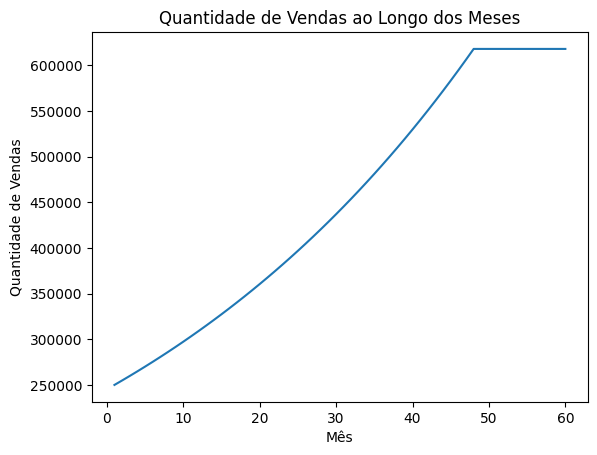

In [95]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.Q[t].value for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

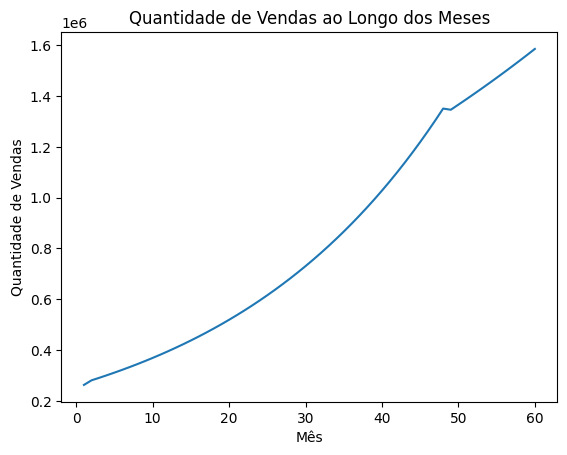

In [96]:
import matplotlib.pyplot as plt

# plt.plot(range(1, 3), [value(AR_rule(model, t)) for t in range(1, 3)], label='AR')

plt.plot(range(1, T+1), [value(AP_rule(model, t)) for t in range(1, T+1)], label='AP')

# plt.plot(range(1, 3), [value(I_rule(model, t)) for t in range(1, 3)], label='I')

plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses')
plt.show()

# plt.plot(range(1, 3), [value(AP_rule(model, t)) for t in range(1, 3)])
# plt.xlabel('Mês')
# plt.ylabel('Quantidade de Vendas')
# plt.title('Quantidade de Vendas ao Longo dos Meses')
# plt.show()

### Receita por Período

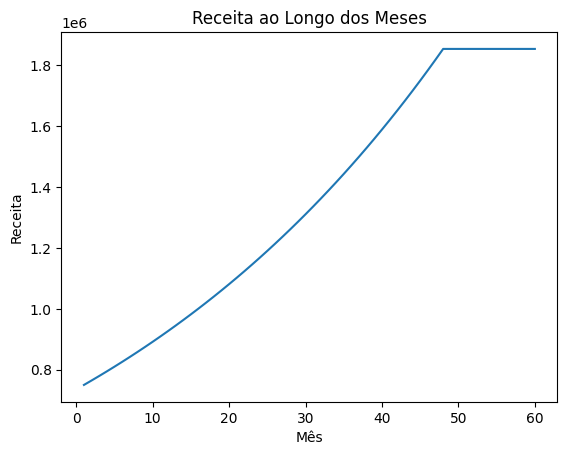

In [97]:
plt.plot(range(1, T+1), [revenue_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses')
plt.show()

### Lucro por Período

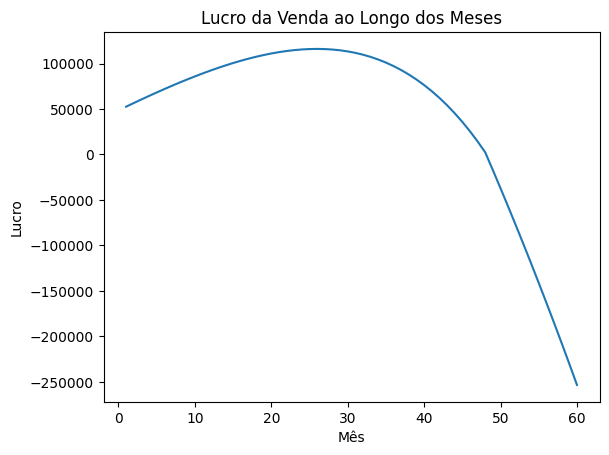

In [98]:
plt.plot(range(1, T+1), [profit_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro da Venda ao Longo dos Meses')
plt.show()

### Fluxo de Caixa Operacional por Período

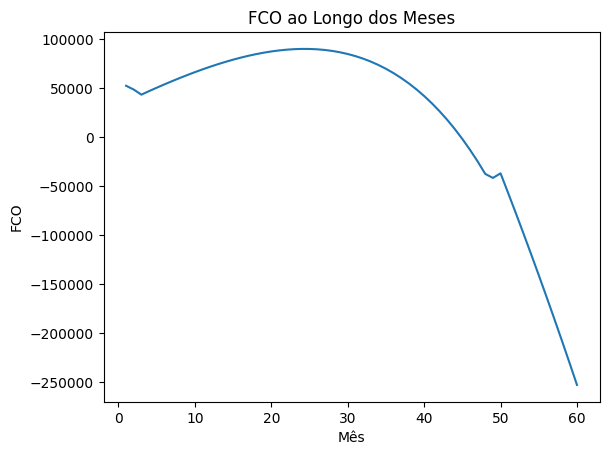

In [99]:
plt.plot(range(1, T+1), [fco_period(model, t) for t in range(1, T+1)])
plt.xlabel('Mês')
plt.ylabel('FCO')
plt.title('FCO ao Longo dos Meses')
plt.show()

# Descobrindo possíveis variações no valor de custos variáveis com base na variação do dólar

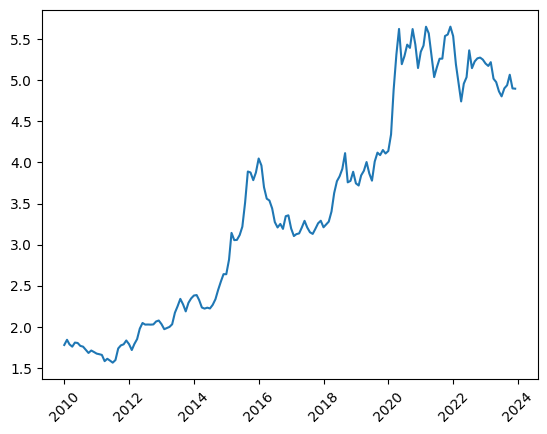

In [100]:
from currency_converter import CurrencyConverter
from datetime import datetime
from numpy import mean
import calendar
import matplotlib.pyplot as plt

c = CurrencyConverter(fallback_on_missing_rate=True)

# Pega a média do dólar mensal desde 2010
dolar_mean = []
for i in range(2010, 2024):
    for j in range(1, 13):
        _, num_days = calendar.monthrange(i, j)
        dolar_mean.append(mean([c.convert(1, 'USD', 'BRL', date=datetime(i, j, k)) for k in range(1, num_days+1)]))

# Plota o gráfico utilizando datas no eixo x
plt.plot([datetime(i, j, 1) for i in range(2010, 2024) for j in range(1, 13)], dolar_mean)
plt.xticks(rotation=45)
plt.show()


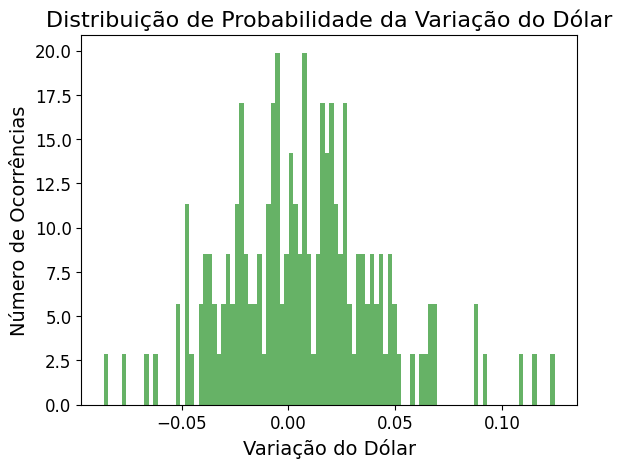

In [101]:
# Distribuição de probabilidades da variação do dólar baseado na série temporal dolar_mean
from scipy.stats import norm
import numpy as np

dolar_mean_variation = np.diff(dolar_mean)

#  Agora uma lista que pega o calor do dolar e soma com a variação
dolar_mean_variation = [(dolar_mean[i] + dolar_mean_variation[i])/dolar_mean[i] - 1 for i in range(len(dolar_mean_variation))]

# plot the histogram
plt.hist(dolar_mean_variation, bins=100, density=True, alpha=0.6, color='g')
plt.xlabel('Variação do Dólar', fontsize=14)
plt.ylabel('Número de Ocorrências', fontsize=14)
plt.title('Distribuição de Probabilidade da Variação do Dólar', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()


## Gerando cenários com o modelo Markoviano

/home/henrique/Documentos/valuation-optimization/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                      y   No. Observations:                  167
Model:               MarkovRegression   Log Likelihood                -440.966
Date:                Mon, 07 Jul 2025   AIC                            893.932
Time:                        11:50:52   BIC                            912.640
Sample:                             0   HQIC                           901.525
                                - 167                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3925      0.333     -1.177      0.239      -1.046       0.261
sigma2         4.0167      1.359      2.957      0.0

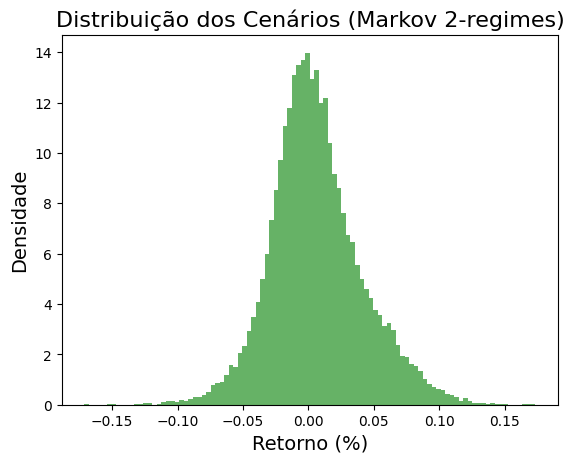

In [102]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching import markov_regression as mr

# ------------------------------------------------------------
# 1) série de retornos (%)
# ------------------------------------------------------------
fx   = pd.Series(dolar_mean, dtype=float)
ret  = 100 * np.log(fx).diff().dropna()        # log-retorno mensal em %

# ------------------------------------------------------------
# 2) ajusta Markov (2 regimes) com média e variância diferentes
# ------------------------------------------------------------
mod  = mr.MarkovRegression(ret,
                           k_regimes=2,
                           trend='c',                # constante por regime
                           switching_variance=True)  # σ² muda por regime
res  = mod.fit(disp=False)
print(res.summary())

# ------------------------------------------------------------
# 3) estima matriz de transição e momentos por regime
# ------------------------------------------------------------
# regime estimado em cada ponto (mais provável)
regimes = res.smoothed_marginal_probabilities.idxmax(axis=1)

# matriz de transição P_ij (contagem / soma linha)
P = np.zeros((2, 2))
for (i, j) in zip(regimes[:-1], regimes[1:]):
    P[i, j] += 1
P = (P.T / P.sum(axis=1)).T         # normaliza linhas

# médias e desvios condicionais
mu  = ret.groupby(regimes).mean().values
sig = ret.groupby(regimes).std().values

print("Médias regimes:", mu, "\nDesvios regimes:", sig, "\nTransição:\n", P)

# ------------------------------------------------------------
# 4) simula caminhos de retorno
# ------------------------------------------------------------
np.random.seed(42)
steps     = T - 1
scenarios = 500
paths = np.zeros((scenarios, steps))

# distribuição estacionária dos regimes (solução de πP = π)
eigvals, eigvecs = np.linalg.eig(P.T)
stat_dist = np.real(eigvecs[:, np.isclose(eigvals, 1)])
stat_dist = stat_dist / stat_dist.sum()

for s in range(scenarios):
    r = np.random.choice([0, 1], p=stat_dist.flatten())   # regime inicial
    for t in range(steps):
        # gera retorno para o período t
        paths[s, t] = np.random.normal(mu[r], sig[r])
        # sorteia próximo regime
        r = np.random.choice([0, 1], p=P[r])

# ------------------------------------------------------------
# 5) grava no formato antigo  (coluna única empilhada)
# ------------------------------------------------------------
scenarios_data_markov = (paths / 100).reshape(-1, 1)
pickle.dump(scenarios_data_markov, open('all_data_markov.pkl', 'wb'))

# ------------------------------------------------------------
# 6) histograma de todos os retornos simulados (opcional)
# ------------------------------------------------------------
plt.hist(scenarios_data_markov, bins=100, density=True,
         alpha=0.6, color='g')
plt.title('Distribuição dos Cenários (Markov 2-regimes)', fontsize=16)
plt.xlabel('Retorno (%)', fontsize=14)
plt.ylabel('Densidade', fontsize=14)
plt.show()

# https://chatgpt.com/s/t_6855c1fbc160819194a524813d34e4de


## Uso de moment matching para gerar os retornos

In [103]:
# Extrair os parâmetros dos dados
target_mean = np.mean(dolar_mean_variation)
target_variance = np.var(dolar_mean_variation)
target_skewness = np.mean((dolar_mean_variation - target_mean)**3) / target_variance**(3/2)
target_kurtosis = np.mean((dolar_mean_variation - target_mean)**4) / target_variance**2


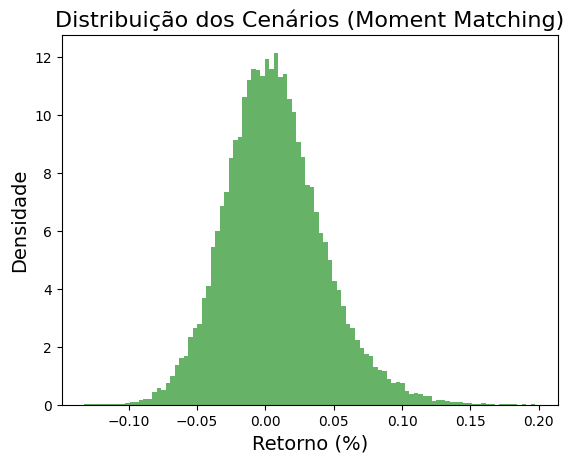

In [104]:
# Baseado no https://bjerring.github.io/equity/2019/12/12/Scenario-Generation-and-Moment-Matching.html

import numpy as np
from scipy.stats import skew, kurtosis
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pickle

def moment_matching_func(x, *args):
    """Função de ajuste de momentos que minimiza o erro entre os cenários gerados e os momentos-alvo."""
    para_match = args[0]
    exp_mu, exp_sds, exp_skew, exp_kur, exp_cov_m = para_match

    # Calcula a matriz de correlação a partir da covariância
    std_ = np.sqrt(np.diag(exp_cov_m)) if exp_cov_m.ndim > 1 else np.sqrt(exp_cov_m)
    exp_cor_m = exp_cov_m / np.outer(std_, std_) if exp_cov_m.ndim > 1 else 1.0

    # Reshape dos cenários gerados
    xx = np.reshape(x, (-1, len(exp_mu)))

    # Calcula os momentos dos cenários
    m1 = np.mean(xx, axis=0)
    m2 = np.std(xx, axis=0)
    m3 = [skew(xx[:, i]) for i in range(len(exp_mu))]
    m4 = [kurtosis(xx[:, i]) for i in range(len(exp_mu))]

    # Calcula o erro como a soma dos quadrados das diferenças
    epsilon = (np.sum((m1 - exp_mu)**2) +
               np.sum((m2 - exp_sds)**2) +
               np.sum((m3 - exp_skew)**2) +
               np.sum((m4 - exp_kur)**2) +
               np.sum((np.corrcoef(xx, rowvar=False) - exp_cor_m)**2))

    return epsilon

def generate_scenarios_with_moment_matching(mu, sigma, skewness, kurtosis, covariance, size=10000):
    """
    Gera cenários ajustando os momentos estatísticos fornecidos.
    """
    # Define os momentos-alvo
    para_match = (mu, sigma, skewness, kurtosis, covariance)

    # Verifica se a covariância é escalar (para uma variável)
    if covariance.ndim == 1:
        covariance = np.array([[covariance[0]]])  # Torna a matriz 2D para compatibilidade

    # Inicializa os cenários com uma distribuição normal multivariada
    x_ini = np.random.multivariate_normal(mu, covariance, size).ravel()

    # Minimiza o erro entre os momentos gerados e os momentos-alvo
    res = minimize(moment_matching_func, x_ini, method='CG', args=(para_match,))

    # Retorna os cenários ajustados
    scenarios = np.reshape(res.x, (-1, len(mu)))

    return scenarios

def extract_moments_and_covariance(data):
    """
    Extrai os momentos estatísticos e a matriz de covariância dos dados fornecidos.
    """
    mu = np.mean(data, axis=0)
    sigma = np.std(data, axis=0)
    skewness = skew(data, axis=0)
    kurtosis_vals = kurtosis(data, axis=0)
    covariance = np.cov(data, rowvar=False)
    
    # Se for uma variável, ajuste a covariância para ser um array
    if covariance.ndim == 0:
        covariance = np.array([[covariance]])
    
    return mu, sigma, skewness, kurtosis_vals, covariance

# Parâmetros dos cenários
scenarios = 500  # Número de cenários
initial_variable_costs = 0.35
dolar_affect_parameter = 0.5
if GENERATE_NEW_SCENARIOS:

    # Substitua pelo histórico da variação do dólar
    historical_data = np.array(dolar_mean_variation).reshape(-1, 1)
    mu, sigma, skewness, kurtosis_vals, covariance = extract_moments_and_covariance(historical_data)

    # Gera os cenários
    scenarios_data = []

        # Gerando valor ajustado aos momentos
    data_point = generate_scenarios_with_moment_matching(
        mu=mu, 
        sigma=sigma, 
        skewness=skewness, 
        kurtosis=kurtosis_vals, 
        covariance=covariance, 
        size=(T-1)*scenarios # Subtraio 1 pois o primeiro mês é o valor percentual inicial
    )
        
    scenarios_data = data_point

    all_data = scenarios_data.copy()

    pickle.dump(scenarios_data, open('all_data.pkl', 'wb'))

else:
    all_data = pickle.load(open('all_data.pkl', 'rb'))

# Visualiza os dados de todos os cenários
plt.hist(all_data, bins=100, density=True,
         alpha=0.6, color='g')
plt.title('Distribuição dos Cenários (Moment Matching)', fontsize=16)
plt.xlabel('Retorno (%)', fontsize=14)
plt.ylabel('Densidade', fontsize=14)
plt.show()




In [105]:
# scenarios_alt = np.zeros((scenarios, T))

if GENERATE_NEW_SCENARIOS:
    scenarios_data = all_data.reshape(scenarios, (T-1)).tolist()

    values = []
    for i in range(scenarios):
        values_list = [initial_variable_costs]
        for t in range(1, T):
            values_list.append(values_list[t-1] + scenarios_data[i][t-1] * dolar_affect_parameter)
        values.append(values_list)

    scenarios_data = values

    pickle.dump(scenarios_data, open('scenarios_data.pkl', 'wb'))

else:
    scenarios_data = pickle.load(open('scenarios_data.pkl', 'rb'))



# Modelo Múltiplo

In [106]:
from pyomo.environ import *

# Cria um modelo concreto
model = ConcreteModel()

# Períodos
T=60

# Variáveis de decisão, agora são T * scenarios
model.P = Param(initialize=P_min)
model.Q = Var(range(1, scenarios+1), range(1, T+1), bounds=(Q_min, Q_max*2), within=NonNegativeReals)

# Parâmetros de custos, despesas e impostos
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Agora variable_cost_percentage é um parâmetro que varia em cada cenário
model.variable_cost_percentage = Param(range(1, scenarios+1), range(1, T+1), initialize=lambda model, i, j: scenarios_data[i-1][j-1])

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=inital_sales)
for i in range(1, scenarios+1):
    model.Q[i, 1].fix(model.initial_quantity)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# Expressões Auxiliares Gerais
def revenue_rule(model, i, t):
    return model.P * model.Q[i, t]

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, i, t):
    # return 0
    return revenue_rule(model, i, t) * model.theta_AR

def I_rule(model, i, t):
    # return 0
    return (model.variable_cost_percentage[i, t] * revenue_rule(model, i, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, i, t):
    i_t_minus_1 = I_rule(model, i, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, i, t) + model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, i, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - (AR_rule(model, i, t-1) + I_rule(model, i, t-1) - AP_rule(model, i, t-1) if t > 1 else model.initial_NCG)
    else:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - model.initial_NCG


# Função objetivo

# def objective_rule(model):
#     t_final = T
#     return sum(sum(revenue_rule(model, i, t_period) -\
#         model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
#         model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
#         model.taxes_percentage * revenue_rule(model, i, t_period) - \
#         model.fix_costs - model.fix_expenses - \
#         NCG_rule(model, i, t_period) for i in range(1, scenarios+1))/scenarios for t_period in range(t_final-months_future_FCO+1, t_final+1)) 

def fcf_period_expression(model, i, t_period):
    return (revenue_rule(model, i, t_period) - 
            model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - 
            model.variable_expenses_percentage * revenue_rule(model, i, t_period) - 
            model.taxes_percentage * revenue_rule(model, i, t_period) - 
            model.fix_costs - model.fix_expenses - 
            NCG_rule(model, i, t_period))

def calculate_wacc(E, D, Ke, Kd, IR):
    """
    Calcula o WACC com base na fórmula fornecida:
    WACC = (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)
    """
    return (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)

def objective_rule(model):
    t_final = T
    # Valores de exemplo para os parâmetros do WACC (substitua pelos valores reais do modelo)
    E = 0.7  # Capital próprio
    D = 0.3  # Dívida
    Ke = 0.1  # Custo do capital próprio
    Kd = 0.05  # Custo da dívida
    IR = 0.3  # Taxa de imposto

    WACC = calculate_wacc(E, D, Ke, Kd, IR)

    return sum(
        sum(
            fcf_period_expression(model, i, t_period) / ((1 + WACC) ** t_period)
            for i in range(1, scenarios + 1)
        ) / scenarios
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

model.objective = Objective(rule=objective_rule, sense=maximize)

# Restrição de demanda
def demand_rule(model, t):
    return model.P[t] == model.a - model.b * model.Q[t]

# model.demand = Constraint(range(1, T+1), rule=demand_rule)

def fco_rule(model, i, t):
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t)) >= 0

# model.fco = Constraint(range(1, scenarios+1), range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
# BREAKPOINT
def growth_rule(model, i, t):
    return model.Q[i, t] <= model.Q[i, t-1] * growth_rate if t > 1 else model.Q[i, t] <= model.initial_quantity

model.growth = Constraint(range(1, scenarios+1), range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, i, t):
    if t <= 2:
        # return pyomo true
        return revenue_rule(model, i, t) <= 10e10
    
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses) >= ((revenue_rule(model, i, t-1) -\
        model.variable_cost_percentage[i, t-1] * revenue_rule(model, i, t-1) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t-1) - \
        model.taxes_percentage * revenue_rule(model, i, t-1) - \
        model.fix_costs - model.fix_expenses) * profit_increment_rate)

# model.profit = Constraint(range(1, scenarios+1), range(1, T+1), rule=profit_rule)

def non_regression_rule(model, i, t):
    return model.Q[i, t] >= model.Q[i, t-1] if t > 1 else model.Q[i, t] >= model.initial_quantity

model.non_regression = Constraint(range(1, scenarios+1), range(1, T+1), rule=non_regression_rule)

# Componentes da NCG
model.AR = Expression(range(1, scenarios+1), range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, scenarios+1), range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, scenarios+1), range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, scenarios+1), range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory(solver_name)
# solver.options['NonConvex'] = 2
result = solver.solve(model, tee=True)

# Exibir os resultados
# for t in range(1, T+1):
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}')
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms


## Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [107]:
from pyomo.environ import value


def fco_period_multiple(model, i, t):
    return value(model.P * model.Q[i, t] - model.variable_cost_percentage[i, t] * model.P * model.Q[i, t] - model.variable_expenses_percentage * model.P * model.Q[i, t] - model.taxes_percentage * model.P * model.Q[i, t] - model.fix_costs - model.fix_expenses - model.NCG[i, t])

def revenue_period_multiple(model, i, t):
    return value(model.P * model.Q[i, t])

def profit_period_multiple(model, i, t):
    return value(model.P * model.Q[i, t] - model.variable_cost_percentage[i, t] * model.P * model.Q[i, t] - model.variable_expenses_percentage * model.P * model.Q[i, t] - model.taxes_percentage * model.P * model.Q[i, t] - model.fix_costs - model.fix_expenses)

## Gráficos de Comportamento da Solução

### Quantidade de Vendas por Período

Text(0.5, 1.0, 'Quantidade de Vendas ao Longo dos Meses Para Cada Cenário')

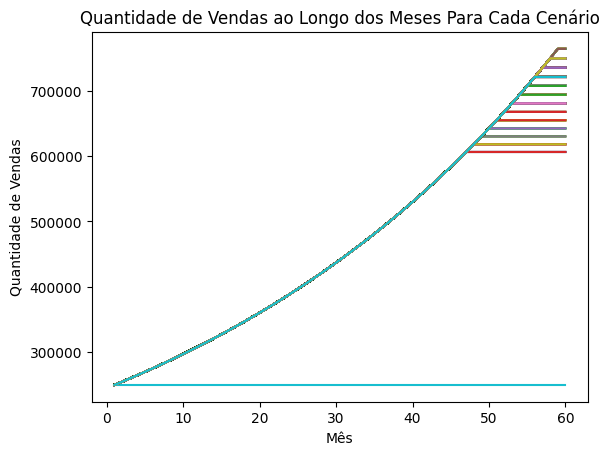

In [108]:
# plot de preço e quantidade para cada cenário
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [model.Q[i, t].value for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Quantidade de Vendas')
plt.title('Quantidade de Vendas ao Longo dos Meses Para Cada Cenário')

### Receita por Período

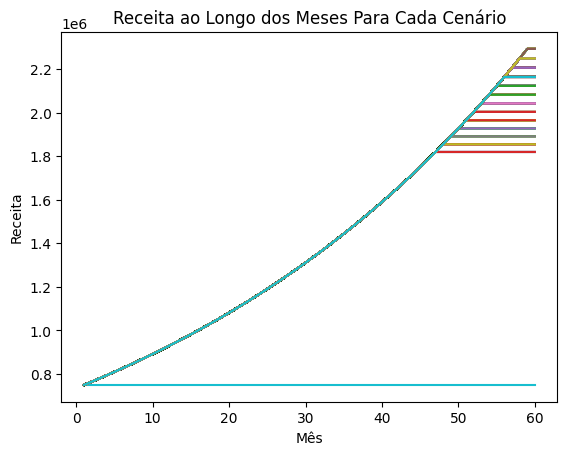

In [109]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

### Lucro por Período

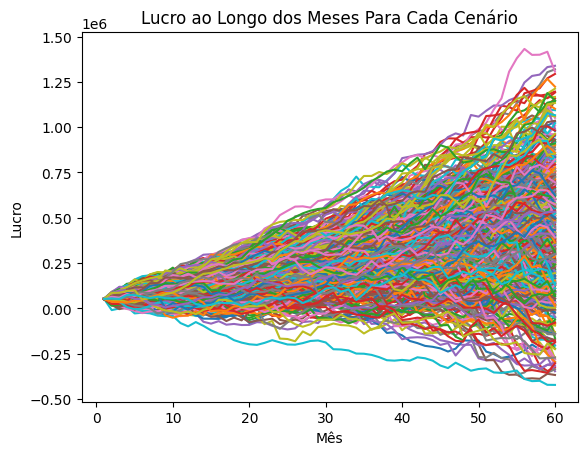

In [110]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

### Fluxo de Caixa Operacional por Período

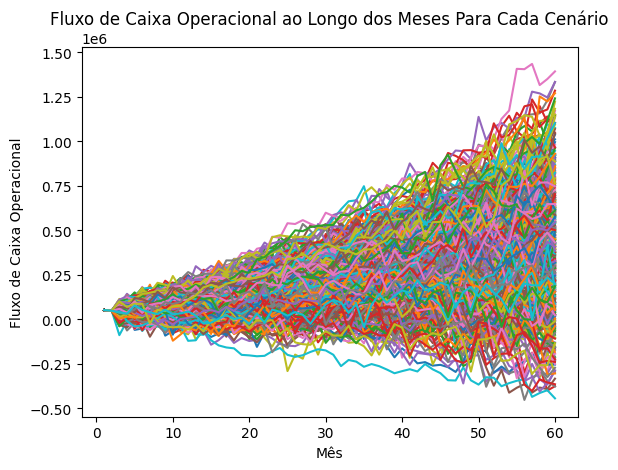

In [111]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period_multiple(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Fluxo de Caixa Operacional')
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário')
plt.show()

# Modelo Estocástico Mono-objetivo | FCO Último Ano

In [112]:
from pyomo.environ import *

# Cria um modelo concreto
stochastic_model = model = ConcreteModel()

# Períodos
T=60

# Variáveis de decisão, agora são T * scenarios
model.P = Param(initialize=P_min)
model.Q = Var(range(1, T+1), bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

# Parâmetros de custos, despesas e impostos
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Agora variable_cost_percentage é um parâmetro que varia em cada cenário
model.variable_cost_percentage = Param(range(1, scenarios+1), range(1, T+1), initialize=lambda model, i, j: scenarios_data[i-1][j-1], mutable=True)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=inital_sales)
model.Q[1].fix(model.initial_quantity)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# Expressões Auxiliares Gerais
def revenue_rule(model, i, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, i, t):
    # return 0
    return revenue_rule(model, i, t) * model.theta_AR

def I_rule(model, i, t):
    # return 0
    return (model.variable_cost_percentage[i, t] * revenue_rule(model, i, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, i, t):
    i_t_minus_1 = I_rule(model, i, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, i, t) + model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, i, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - (AR_rule(model, i, t-1) + I_rule(model, i, t-1) - AP_rule(model, i, t-1) if t > 1 else model.initial_NCG)
    else:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - model.initial_NCG

def fcf_period_expression(model, i, t_period):
    """
    Calcula o fluxo de caixa livre (FCF) para um dado cenário e período.
    """
    revenue = revenue_rule(model, i, t_period)
    variable_costs = model.variable_cost_percentage[i, t_period] * revenue
    variable_expenses = model.variable_expenses_percentage * revenue
    taxes = model.taxes_percentage * revenue
    fixed_costs = model.fix_costs + model.fix_expenses
    ncg = NCG_rule(model, i, t_period)

    return revenue - variable_costs - variable_expenses - taxes - fixed_costs - ncg

def calculate_wacc(E, D, Ke, Kd, IR):
    """
    Calcula o WACC com base na fórmula fornecida:
    WACC = (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)
    """
    return (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)

def objective_rule(model):
    """
    Calcula a função objetivo considerando o fluxo de caixa livre (FCF) descontado
    para múltiplos cenários e períodos.
    """
    t_final = T
    # Valores de exemplo para os parâmetros do WACC (substitua pelos valores reais do modelo)
    E = 0.7  # Capital próprio
    D = 0.3  # Dívida
    Ke = 0.1  # Custo do capital próprio
    Kd = 0.05  # Custo da dívida
    IR = 0.3  # Taxa de imposto

    WACC = calculate_wacc(E, D, Ke, Kd, IR)

    return sum(
        sum(
            fcf_period_expression(model, i, t_period) / ((1 + WACC) ** t_period)
            for i in range(1, scenarios + 1)
        ) / scenarios
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

model.objective = Objective(rule=objective_rule, sense=maximize)

def other_objective_rule(model):
    gamma = GAMMA
    t_final = T
    # soma FCO_i / (1 + gamma)^t
    return sum(sum((revenue_rule(model, i, t_period) -\
        model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
        model.taxes_percentage * revenue_rule(model, i, t_period) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t_period)) / (1 + gamma)**t_period for i in range(1, scenarios+1))/scenarios for t_period in range(1, t_final+1))

def fco_rule(model, i, t):
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t)) >= 0

# model.fco = Constraint(range(1, scenarios+1), range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, i, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, scenarios+1), range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, i, t):
    if t <= 2:
        # return pyomo true
        return revenue_rule(model, i, t) <= 10e10
    
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses) >= ((revenue_rule(model, i, t-1) -\
        model.variable_cost_percentage[i, t-1] * revenue_rule(model, i, t-1) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t-1) - \
        model.taxes_percentage * revenue_rule(model, i, t-1) - \
        model.fix_costs - model.fix_expenses) * profit_increment_rate)

# model.profit = Constraint(range(1, scenarios+1), range(1, T+1), rule=profit_rule)

def fco_rule_exp(model, i):
    t_final = T
    return -sum(revenue_rule(model, i, t_period) -\
        model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
        model.taxes_percentage * revenue_rule(model, i, t_period) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t_period) for t_period in range(t_final-months_future_FCO+1, t_final+1))

model.FCO = Expression(S_range, rule=fco_rule_exp)

def non_regression_rule(model, i, t):
    return model.Q[t] >= model.Q[t-1] if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, scenarios+1), range(1, T+1), rule=non_regression_rule)

# Componentes da NCG
model.AR = Expression(range(1, scenarios+1), range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, scenarios+1), range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, scenarios+1), range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, scenarios+1), range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory(solver_name)
# solver.options['NonConvex'] = 2
result = solver.solve(model, tee=True)

# Exibir os resultados
# for t in range(1, T+1):
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}')
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms


## Criação de Funções auxiliares para calcular Receita, Lucro e FCO

In [113]:
from pyomo.environ import value


def fco_period(model, i, t):
    return value(3 * model.Q[t] - model.variable_cost_percentage[i, t] * 3 * model.Q[t] - model.variable_expenses_percentage * 3 * model.Q[t] - model.taxes_percentage * 3 * model.Q[t] - model.fix_costs - model.fix_expenses - model.NCG[i, t])

def revenue_period(model, i, t):
    return value(3 * model.Q[t])

def profit_period(model, i, t):
    return value(3 * model.Q[t] - model.variable_cost_percentage[i, t] * 3 * model.Q[t] - model.variable_expenses_percentage * 3 * model.Q[t] - model.taxes_percentage * 3 * model.Q[t] - model.fix_costs - model.fix_expenses)

## Quantidade de Vendas por Período

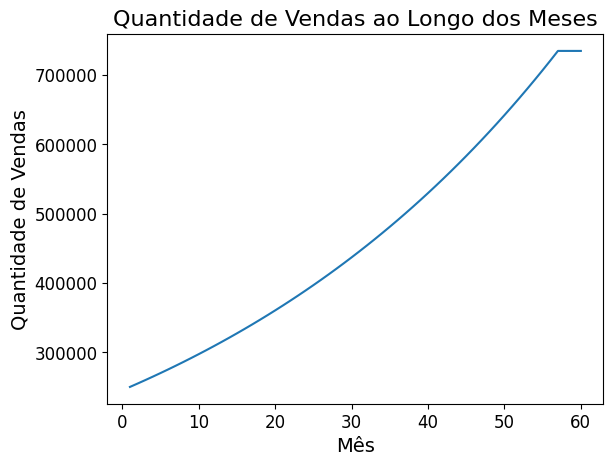

[250000.0, 254861.50000000003, 259817.53672900004, 264869.9485482322, 270020.6095677012, 275271.4303413547, 280624.35857577267, 286081.3798526372, 291644.5183652516, 297315.8376693823, 303097.44144870114, 308991.4742951126, 315000.1225042554, 321125.61488647317, 327370.22359355557, 333736.2649615559, 340226.1003699983, 346842.1371177933, 353586.82931618596, 360462.67879906856, 367472.23605099524, 374618.1011532429, 381902.9247482689, 389329.4090229238, 396900.3087107836, 404618.43211397354, 412486.6421448619, 420507.85738801095, 428685.05318277824, 437021.2627269706, 445519.5782019593, 454183.15191967465, 463015.19749190466, 472018.9910223323, 481197.8723217526, 490555.2461469214, 500094.5834634945, 509819.42273352563, 519733.3712280018, 529840.1063649015, 540143.3770732734, 550647.0051838403, 561354.8868466453, 572270.9939762652, 583399.3757251276, 594744.1599854785, 606309.5549205561, 618099.8505255413, 630119.4202188611, 642372.7224644371, 654864.3024254807, 667598.7936504466, 68058

In [114]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.Q[t].value for t in range(1, T+1)])
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Quantidade de Vendas', fontsize=14)
plt.title('Quantidade de Vendas ao Longo dos Meses', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print([model.Q[t].value for t in range(1, T+1)])

## Receita por Período

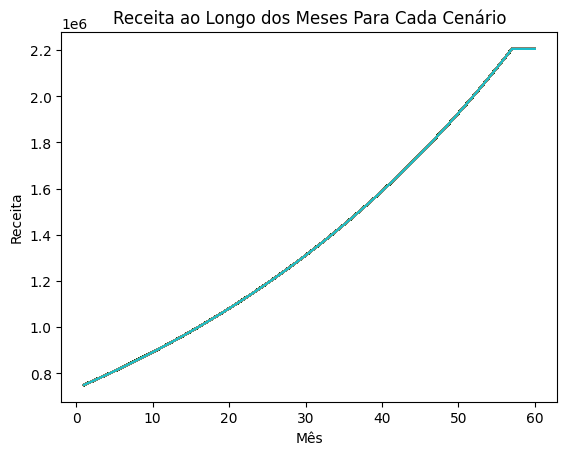

In [115]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

## Lucro por Período

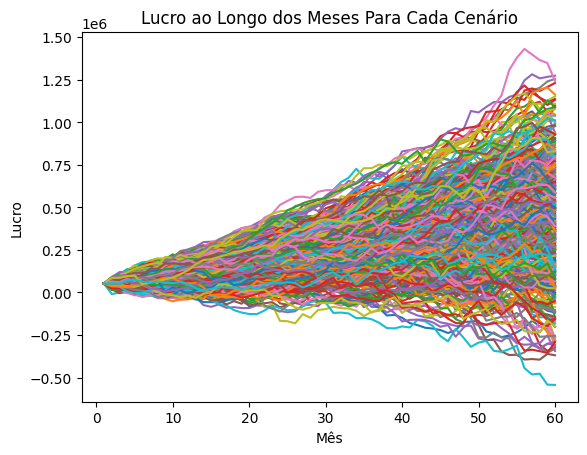

In [116]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fluxo de Caixa Operacional por Período

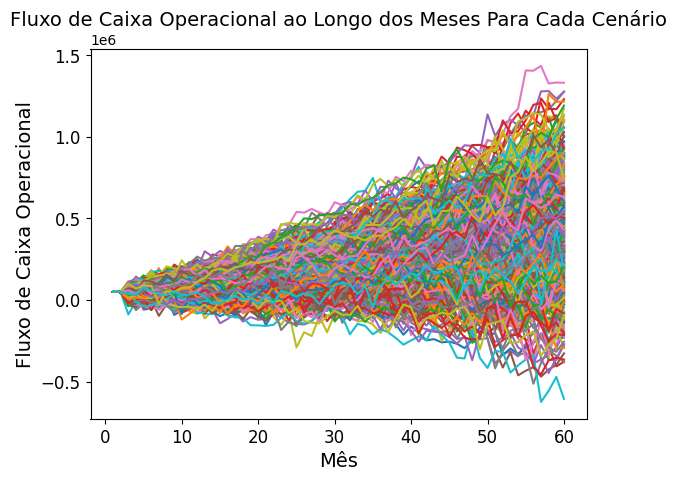

In [117]:


for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

# aumentar tamanho do titulo e dos eixos

plt.xlabel('Mês', fontsize=14)
plt.ylabel('Fluxo de Caixa Operacional', fontsize=14)
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## Distribuição de FCO

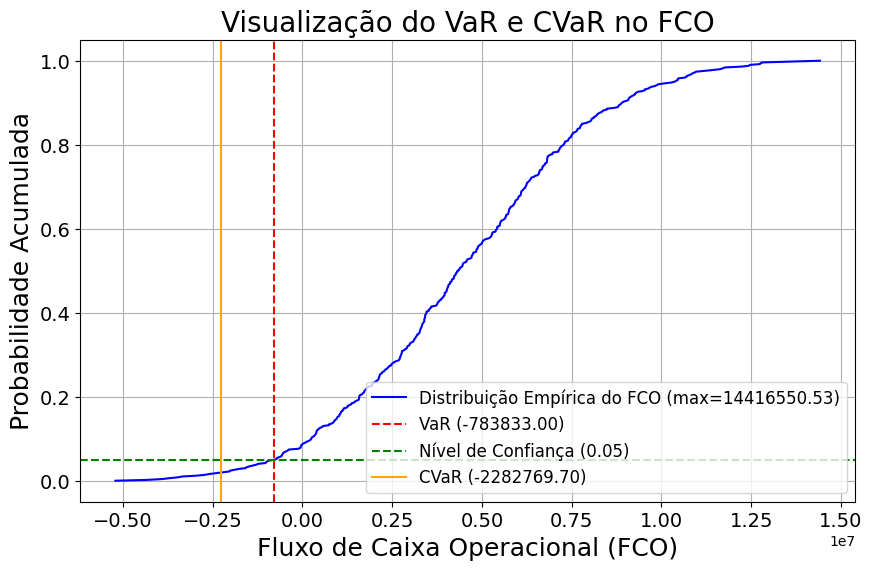

In [118]:
fco_values = [-value(model.FCO[i]) for i in S_range]

# descbrir var e cvar por cálculo, não utilizar model.VaR
var_value = sorted(fco_values)[int(len(fco_values) * 0.05)]
cvar_value = sum([fco for fco in fco_values if fco < var_value]) / int(len(fco_values) * 0.05)
alpha=0.95

import matplotlib.pyplot as plt
import numpy as np

# Dados
scenarios_results = list(S_range)
fco_values_sorted = sorted(fco_values)  # Ordenar FCO para visualização
cum_probs = np.linspace(0, 1, len(fco_values_sorted))  # Probabilidade acumulada

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(fco_values_sorted, cum_probs, label=f'Distribuição Empírica do FCO (max={round(max(fco_values), 2)})', color='blue')
plt.axvline(x=var_value, color='red', linestyle='--', label=f'VaR ({var_value:.2f})')
plt.axhline(y=(1-alpha), color='green', linestyle='--', label=f'Nível de Confiança ({1-alpha:.2f})')
plt.axvline(x=cvar_value, color='orange', linestyle='-', label=f'CVaR ({cvar_value:.2f})')

# Anotações
plt.title('Visualização do VaR e CVaR no FCO', fontsize=20)
plt.xlabel('Fluxo de Caixa Operacional (FCO)', fontsize=18)
plt.ylabel('Probabilidade Acumulada', fontsize=18)
plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)

# Exibir
plt.show()

## Valores das 2 funções objetivo

In [119]:
print(f'Valor da Função Objetivo FCO: {model.objective()}')
print(f'Valor da Função NPV por GUROBI: {value(other_objective_rule(model))}')
print(f'Valor da Função NPV por Cálculo : {value(sum(sum((revenue_rule(model, i, t_period) -\
        model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
        model.taxes_percentage * revenue_rule(model, i, t_period) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t_period)) / (1 + GAMMA)**t_period for i in range(1, scenarios+1))/scenarios for t_period in range(1, T+1)))}')

Valor da Função Objetivo FCO: 67109.29033955117
Valor da Função NPV por GUROBI: 8756424.835227145
Valor da Função NPV por Cálculo : 8756424.835227145


# Modelo Estocástico Mono-objetivo | CVaR

In [120]:
from pyomo.environ import *

# Cria um modelo concreto
stochastic_model = model = ConcreteModel()

# Períodos
T=60
S = range(1, 500+1)  # Cenários

# Variáveis de decisão, agora são T * scenarios
model.P = Param(initialize=3)
model.Q = Var(range(1, T+1), bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

# Variáveis para CVaR
model.VarDev = Var(S, within=NonNegativeReals)  # Desvio por cenário
model.VaR = Var(within=Reals)        # Valor em Risco (VaR)
model.CVaR = Var(within=Reals)       # CVaR

# Parâmetros de custos, despesas e impostos
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Agora variable_cost_percentage é um parâmetro que varia em cada cenário
model.variable_cost_percentage = Param(range(1, scenarios+1), range(1, T+1), initialize=lambda model, i, j: scenarios_data[i-1][j-1], mutable=True)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=inital_sales)
model.Q[1].fix(model.initial_quantity)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# Expressões Auxiliares Gerais
def revenue_rule(model, i, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, i, t):
    # return 0
    return revenue_rule(model, i, t) * model.theta_AR

def I_rule(model, i, t):
    # return 0
    return (model.variable_cost_percentage[i, t] * revenue_rule(model, i, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, i, t):
    i_t_minus_1 = I_rule(model, i, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, i, t) + model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, i, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - (AR_rule(model, i, t-1) + I_rule(model, i, t-1) - AP_rule(model, i, t-1) if t > 1 else model.initial_NCG)
    else:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - model.initial_NCG

def fco_rule(model, i, t):
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t)) >= 0

# model.fco = Constraint(range(1, scenarios+1), range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, i, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, scenarios+1), range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, i, t):
    if t <= 2:
        # return pyomo true
        return revenue_rule(model, i, t) <= 10e10
    
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses) >= ((revenue_rule(model, i, t-1) -\
        model.variable_cost_percentage[i, t-1] * revenue_rule(model, i, t-1) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t-1) - \
        model.taxes_percentage * revenue_rule(model, i, t-1) - \
        model.fix_costs - model.fix_expenses) * profit_increment_rate)

# model.profit = Constraint(range(1, scenarios+1), range(1, T+1), rule=profit_rule)

def non_regression_rule(model, i, t):
    return model.Q[t] >= model.Q[t-1] if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, scenarios+1), range(1, T+1), rule=non_regression_rule)

# Restrições para o CVaR
# Restrição para desvio por cenário
def fco_rule_exp(model, i):
    t_final = T
    return -sum(revenue_rule(model, i, t_period) -\
        model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
        model.taxes_percentage * revenue_rule(model, i, t_period) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t_period) for t_period in range(t_final-months_future_FCO+1, t_final+1))

model.FCO = Expression(S, rule=fco_rule_exp)

def vardev_rule(model, i):
    return model.FCO[i] - model.VaR <= model.VarDev[i]

model.vardev_constraint = Constraint(S, rule=vardev_rule)

# Restrição para definição do CVaR
def cvar_rule(model):
    alpha=0.05
    return model.VaR + (1 / (len(S) * alpha)) * sum(model.VarDev[i] for i in S) == model.CVaR

model.cvar_constraint = Constraint(rule=cvar_rule)

# minimizar o CVaR
model.objective = Objective(expr=model.CVaR, sense=minimize)

# Componentes da NCG
model.AR = Expression(range(1, scenarios+1), range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, scenarios+1), range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, scenarios+1), range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, scenarios+1), range(1, T+1), rule=NCG_rule)

# Resolver o modelo
solver = SolverFactory(solver_name)
result = solver.solve(model, tee=True)

# Exibir os resultados
# for t in range(1, T+1):
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}')
    # print(f'Mês {t}: Preço = {model.P[t].value}, Quantidade = {model.Q[t].value}, AR = {model.AR[t].value}, Estoque = {model.I[t].value}, AP = {model.AP[t].value}')

Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms


## Quantidade de Vendas por Período

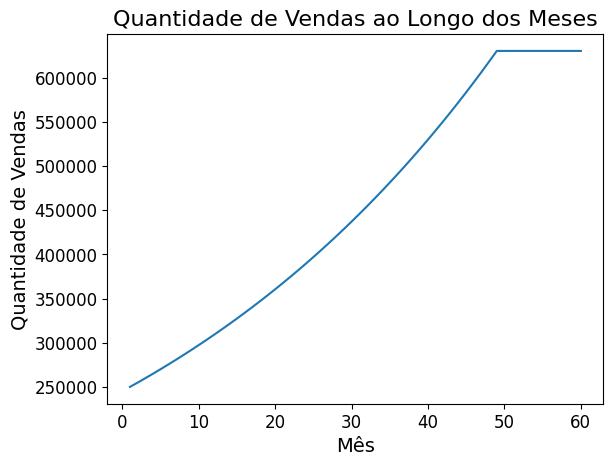

[250000.0, 254861.50000000003, 259817.53672900004, 264869.9485482322, 270020.6095677012, 275271.4303413547, 280624.35857577267, 286081.3798526372, 291644.5183652516, 297315.8376693823, 303097.44144870114, 308991.4742951126, 315000.1225042554, 321125.61488647317, 327370.22359355557, 333736.2649615559, 340226.1003699983, 346842.1371177933, 353586.82931618596, 360462.67879906856, 367472.23605099524, 374618.1011532429, 381902.9247482689, 389329.4090229238, 396900.3087107836, 404618.43211397354, 412486.6421448619, 420507.85738801095, 428685.05318277824, 437021.2627269706, 445519.5782019593, 454183.15191967465, 463015.19749190466, 472018.9910223323, 481197.8723217526, 490555.2461469214, 500094.5834634945, 509819.42273352563, 519733.3712280018, 529840.1063649015, 540143.3770732734, 550647.0051838403, 561354.8868466453, 572270.9939762652, 583399.3757251276, 594744.1599854785, 606309.5549205561, 618099.8505255413, 630119.4202188611, 630119.4202188611, 630119.4202188611, 630119.4202188611, 63011

In [121]:
import matplotlib.pyplot as plt

plt.plot(range(1, T+1), [model.Q[t].value for t in range(1, T+1)])
plt.xlabel('Mês', fontsize=14)
plt.ylabel('Quantidade de Vendas', fontsize=14)
plt.title('Quantidade de Vendas ao Longo dos Meses', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print([model.Q[t].value for t in range(1, T+1)])

## Receita por Período

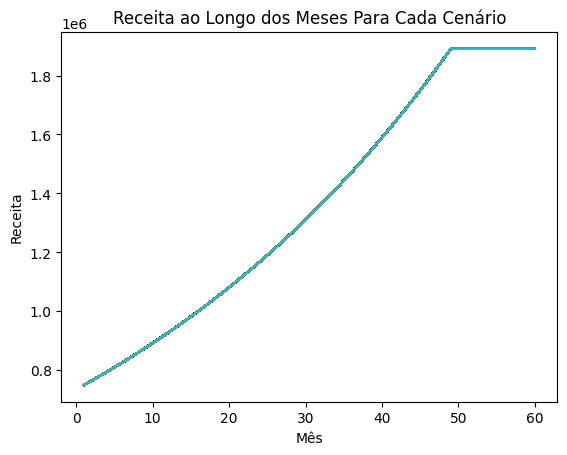

In [122]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [revenue_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Receita')
plt.title('Receita ao Longo dos Meses Para Cada Cenário')
plt.show()

## Lucro por Período

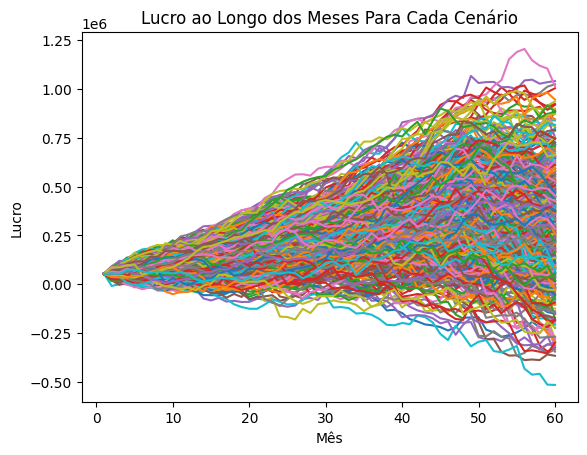

In [123]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [profit_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês')
plt.ylabel('Lucro')
plt.title('Lucro ao Longo dos Meses Para Cada Cenário')
plt.show()

## Fluxo de Caixa Operacional por Período

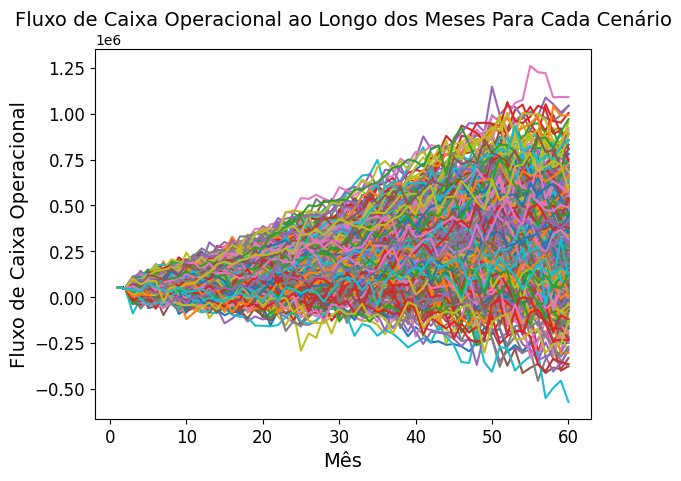

In [124]:
for i in range(1, scenarios+1):
    plt.plot(range(1, T+1), [fco_period(model, i, t) for t in range(1, T+1)], label=f'Cenário {i}')

plt.xlabel('Mês', fontsize=14)
plt.ylabel('Fluxo de Caixa Operacional', fontsize=14)
plt.title('Fluxo de Caixa Operacional ao Longo dos Meses Para Cada Cenário', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

## Distribuição de FCO

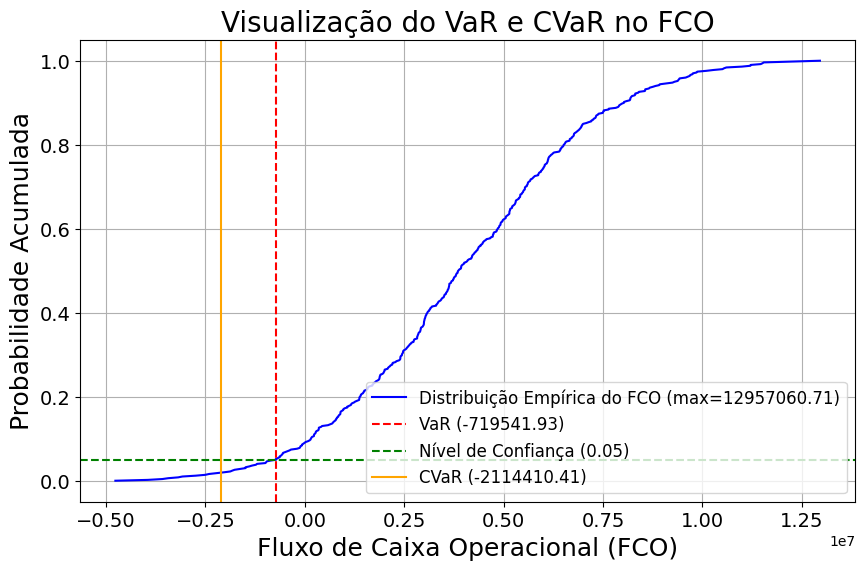

In [125]:
fco_values = [-value(model.FCO[i]) for i in S]

# descbrir var e cvar por cálculo, não utilizar model.VaR
var_value = sorted(fco_values)[int(len(fco_values) * 0.05)]
cvar_value = sum([fco for fco in fco_values if fco < var_value]) / int(len(fco_values) * 0.05)
alpha=0.95

import matplotlib.pyplot as plt
import numpy as np

# Dados
scenarios_results = list(S)
fco_values_sorted = sorted(fco_values)  # Ordenar FCO para visualização
cum_probs = np.linspace(0, 1, len(fco_values_sorted))  # Probabilidade acumulada

# Gráfico
plt.figure(figsize=(10, 6))
plt.plot(fco_values_sorted, cum_probs, label=f'Distribuição Empírica do FCO (max={round(max(fco_values), 2)})', color='blue')
plt.axvline(x=var_value, color='red', linestyle='--', label=f'VaR ({var_value:.2f})')
plt.axhline(y=(1-alpha), color='green', linestyle='--', label=f'Nível de Confiança ({1-alpha:.2f})')
plt.axvline(x=cvar_value, color='orange', linestyle='-', label=f'CVaR ({cvar_value:.2f})')

# Anotações
plt.title('Visualização do VaR e CVaR no FCO', fontsize=20)
plt.xlabel('Fluxo de Caixa Operacional (FCO)', fontsize=18)
plt.ylabel('Probabilidade Acumulada', fontsize=18)
plt.legend(fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)

# Exibir
plt.show()

## Valores das 2 funções objetivo

In [126]:
print(f'Valor da Função Objetivo NPV: {model.objective()}')
print(f'Valor da Função FCO por GUROBI: {value(other_objective_rule(model))}')
print(f'Valor da Função FCO por Cálculo : {sum(sum(fco_period(model, i, t) for i in range(1, scenarios+1))/scenarios for t in range(1, T+1))}')

Valor da Função Objetivo NPV: 2114410.407308657
Valor da Função FCO por GUROBI: 8489225.914991312
Valor da Função FCO por Cálculo : 12345456.838315235


# Criação da Fronteira Pareto - Problema Multi-objetivo

## Teste com CVaR

In [127]:
from pyomo.environ import *

# Cria um modelo concreto
stochastic_model = model = ConcreteModel()

# Períodos
T=60
S = range(1, 500+1)  # Cenários

# Variáveis de decisão, agora são T * scenarios
model.P = Param(initialize=3)
model.Q = Var(range(1, T+1), bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

# Variáveis para CVaR
model.VarDev = Var(S, within=NonNegativeReals)  # Desvio por cenário
model.VaR = Var(within=Reals)        # Valor em Risco (VaR)
model.CVaR = Var(within=Reals)       # CVaR

# Parâmetros de custos, despesas e impostos
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Agora variable_cost_percentage é um parâmetro que varia em cada cenário
model.variable_cost_percentage = Param(range(1, scenarios+1), range(1, T+1), initialize=lambda model, i, j: scenarios_data[i-1][j-1], mutable=True)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=inital_sales)
model.Q[1].fix(model.initial_quantity)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# Expressões Auxiliares Gerais
def revenue_rule(model, i, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, i, t):
    # return 0
    return revenue_rule(model, i, t) * model.theta_AR

def I_rule(model, i, t):
    # return 0
    return (model.variable_cost_percentage[i, t] * revenue_rule(model, i, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, i, t):
    i_t_minus_1 = I_rule(model, i, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, i, t) + model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, i, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - (AR_rule(model, i, t-1) + I_rule(model, i, t-1) - AP_rule(model, i, t-1) if t > 1 else model.initial_NCG)
    else:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - model.initial_NCG

def fcf_period_expression(model, i, t_period):
    """
    Calcula o fluxo de caixa livre (FCF) para um dado cenário e período.
    """
    revenue = revenue_rule(model, i, t_period)
    variable_costs = model.variable_cost_percentage[i, t_period] * revenue
    variable_expenses = model.variable_expenses_percentage * revenue
    taxes = model.taxes_percentage * revenue
    fixed_costs = model.fix_costs + model.fix_expenses
    ncg = NCG_rule(model, i, t_period)

    return revenue - variable_costs - variable_expenses - taxes - fixed_costs - ncg

def calculate_wacc(E, D, Ke, Kd, IR):
    """
    Calcula o WACC com base na fórmula fornecida:
    WACC = (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)
    """
    return (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)

def objective_rule(model):
    """
    Calcula a função objetivo considerando o fluxo de caixa livre (FCF) descontado
    para múltiplos cenários e períodos.
    """
    t_final = T
    # Valores de exemplo para os parâmetros do WACC (substitua pelos valores reais do modelo)
    E = 0.7  # Capital próprio
    D = 0.3  # Dívida
    Ke = 0.1  # Custo do capital próprio
    Kd = 0.05  # Custo da dívida
    IR = 0.3  # Taxa de imposto

    WACC = calculate_wacc(E, D, Ke, Kd, IR)

    return sum(
        sum(
            fcf_period_expression(model, i, t_period) / ((1 + WACC) ** t_period)
            for i in range(1, scenarios + 1)
        ) / scenarios
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

def fco_rule(model, i, t):
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t)) >= 0

# model.fco = Constraint(range(1, scenarios+1), range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, i, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, scenarios+1), range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, i, t):
    if t <= 2:
        # return pyomo true
        return revenue_rule(model, i, t) <= 10e10
    
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses) >= ((revenue_rule(model, i, t-1) -\
        model.variable_cost_percentage[i, t-1] * revenue_rule(model, i, t-1) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t-1) - \
        model.taxes_percentage * revenue_rule(model, i, t-1) - \
        model.fix_costs - model.fix_expenses) * profit_increment_rate)

# model.profit = Constraint(range(1, scenarios+1), range(1, T+1), rule=profit_rule)

def non_regression_rule(model, i, t):
    return model.Q[t] >= model.Q[t-1] if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, scenarios+1), range(1, T+1), rule=non_regression_rule)

# Restrições para o CVaR
# Restrição para desvio por cenário
def fco_rule_exp(model, i):
    t_final = T
    return -sum(revenue_rule(model, i, t_period) -\
        model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
        model.taxes_percentage * revenue_rule(model, i, t_period) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t_period) for t_period in range(t_final-months_future_FCO+1, t_final+1))

model.FCO = Expression(S, rule=fco_rule_exp)

def vardev_rule(model, i):
    return model.FCO[i] - model.VaR <= model.VarDev[i]

model.vardev_constraint = Constraint(S, rule=vardev_rule)

# Restrição para definição do CVaR
def cvar_rule(model):
    alpha=0.05
    return model.VaR + (1 / (len(S) * alpha)) * sum(model.VarDev[i] for i in S) == model.CVaR

model.cvar_constraint = Constraint(rule=cvar_rule)

# Componentes da NCG
model.AR = Expression(range(1, scenarios+1), range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, scenarios+1), range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, scenarios+1), range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, scenarios+1), range(1, T+1), rule=NCG_rule)

In [128]:
# OBJETIVO

solutions = []
pop_x = []

spaced = 100

for i, beta in enumerate(np.linspace(0.001, 1, spaced)):
    print(f'Iteration {i+1}/{spaced}')
    #  remove objective
    if i > 0:
        model.del_component(model.objective)
    model.objective = Objective(expr=-model.CVaR * beta + (1-beta)*objective_rule(model), sense=maximize)
    solver = SolverFactory(solver_name)
    # solver.options['NonConvex'] = 2
    # result = solver.solve(model, tee=True, warmstart=False) # Válido p/ Gurobi
    result = solver.solve(model, tee=True)
    # Beta, CVaR, FCO, NPV, Quantidade Final, Quantidades Mensais, FCOs, FCOs Mensais

    for j in range(1, scenarios+1):
            fcos_scenarios = [fco_period(model, j, t) for t in range(1, T+1)]

    solutions.append((
        beta, 
        value(model.CVaR), 
        value(objective_rule(model)), 
        value(objective_rule(model)),
        value(model.Q[T]),
        [value(model.Q[t]) for t in range(1, T+1)],
        [value(model.FCO[i]) for i in S],
        fcos_scenarios
    ))

    

    x_sol = []

    # 1) P_{i,t}
    #    model.P[i+1, t+1] no Pyomo => lembre-se que no Pyomo o i e t começam em 1..
    for i_scenario in range(scenarios):
        for t_period in range(T):
            x_sol.append(value(model.P))

    # 2) Q_t
    for t_period in range(T):
        x_sol.append(value(model.Q[t_period+1]))

    # 3) VarDev_i (se existir)
    for i_scenario in range(scenarios):
        # Se não estiver usando, pode colocar 0.0
        # ou, se estiver, use value(model.VarDev[i_scenario+1])
        x_sol.append(0.0)

    # 4) VaR e CVaR (2 vars extras)
    x_sol.append(value(model.VaR))
    x_sol.append(value(model.CVaR))

    pop_x.append(x_sol)


solutions


Iteration 1/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 2/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 3/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 4/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 5/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 6/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 7/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 8/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 9/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 10/100
Running HiGHS 1.10.0

[(np.float64(0.001),
  2282769.6992405546,
  67109.29033955117,
  67109.29033955117,
  735083.4992892854,
  [250000.0,
   254861.50000000003,
   259817.53672900004,
   264869.9485482322,
   270020.6095677012,
   275271.4303413547,
   280624.35857577267,
   286081.3798526372,
   291644.5183652516,
   297315.8376693823,
   303097.44144870114,
   308991.4742951126,
   315000.1225042554,
   321125.61488647317,
   327370.22359355557,
   333736.2649615559,
   340226.1003699983,
   346842.1371177933,
   353586.82931618596,
   360462.67879906856,
   367472.23605099524,
   374618.1011532429,
   381902.9247482689,
   389329.4090229238,
   396900.3087107836,
   404618.43211397354,
   412486.6421448619,
   420507.85738801095,
   428685.05318277824,
   437021.2627269706,
   445519.5782019593,
   454183.15191967465,
   463015.19749190466,
   472018.9910223323,
   481197.8723217526,
   490555.2461469214,
   500094.5834634945,
   509819.42273352563,
   519733.3712280018,
   529840.1063649015,
   54014

## Plotagem da Fronteira Pareto

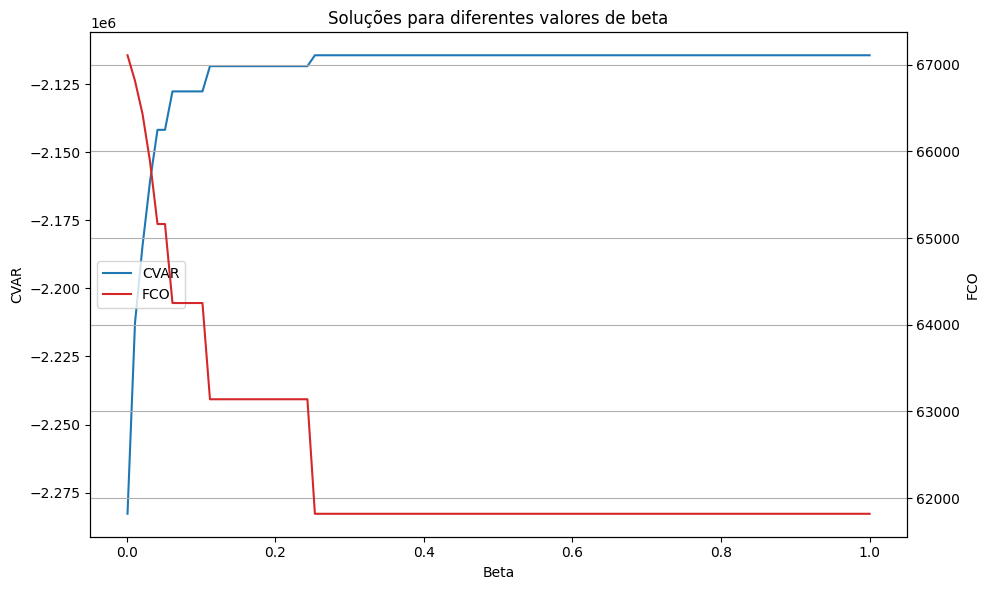

In [129]:
import matplotlib.pyplot as plt

def plot_solutions(solutions):
    # Extraindo as variáveis
    betas = [sol[0] for sol in solutions]
    CVAR = [-sol[1] for sol in solutions]
    FCO = [sol[2] for sol in solutions]

    # Cria a figura e o primeiro eixo
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Cor para a primeira série (CVAR)
    color1 = 'tab:blue'
    ax1.set_xlabel('Beta')
    ax1.set_ylabel('CVAR')
    ax1.plot(betas, CVAR, color=color1, label='CVAR')
    ax1.tick_params(axis='y')
    
    # Cria o segundo eixo (compartilhando o mesmo eixo x)
    ax2 = ax1.twinx()

    # Cor para a segunda série (FCO)
    color2 = 'tab:red'
    ax2.set_ylabel('FCO')
    ax2.plot(betas, FCO, color=color2, label='FCO')
    ax2.tick_params(axis='y')

    # Adiciona título e grade
    plt.title('Soluções para diferentes valores de beta')
    plt.grid(True)
    
    # Ajusta layout para evitar sobreposição
    fig.tight_layout()

    # Cria uma legenda combinada
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='center left',         # Posição da legenda (centro-esquerda)
    bbox_to_anchor=(0.0, 0.5)  # Ajuste da âncora do bounding box
)

    # Exibe o gráfico
    plt.show()

# Chamada de exemplo
plot_solutions(solutions)


In [130]:
solutions_to_plot = [(s[0], s[1], s[2], s[3], s[4], s[5]) for s in solutions]
# solutions_to_plot = np.array(solutions_to_plot)

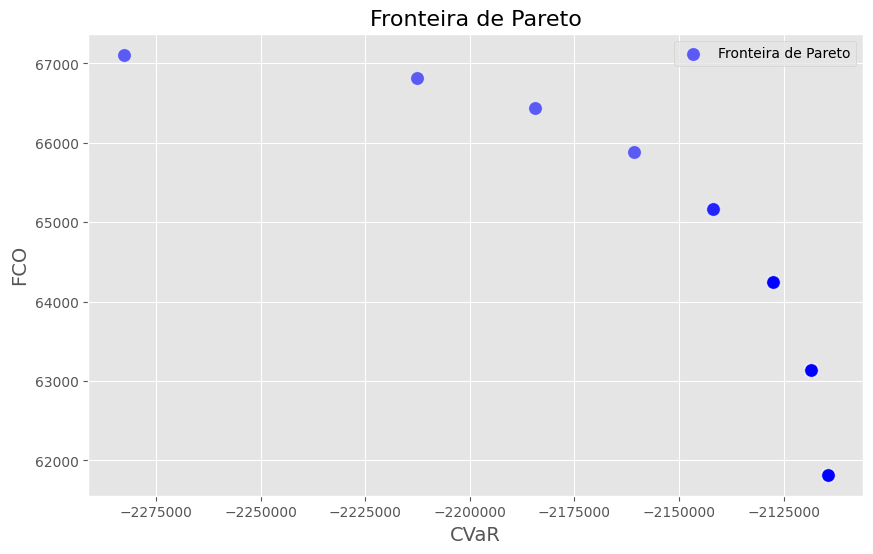

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pareto(solutions):
    plt.style.use('ggplot')
    figsize = (10, 6)
    marker_size = 100
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Converte as soluções para um array numpy para facilitar a manipulação
    # Retira o elemento da posição 5 antes de converter
    solutions = [s[:5] for s in solutions]
    solutions = np.array(solutions)
    
    # Plota os pontos da fronteira de Pareto usando seaborn
    sns.scatterplot(x=[-s for s in solutions[:, 1]], y=solutions[:, 2], color='blue', s=marker_size, alpha=0.6, edgecolor='w', label='Fronteira de Pareto', ax=ax)
    
    # Coloca os eixos como múltiplos de 10^6
    ax.ticklabel_format(axis='x', style='plain')
    ax.ticklabel_format(axis='y', style='plain')
    
    # Melhorias estéticas
    ax.set_xlabel('CVaR', fontsize=14)
    ax.set_ylabel('FCO', fontsize=14)
    ax.set_title('Fronteira de Pareto', fontsize=16)
    ax.legend()
    ax.grid(True)
    
    plt.show()
    
plot_pareto(solutions_to_plot)

## Filtragem da Fronteira Pareto

In [132]:
filtered_solutions = []
filtered_pop_x = []

for i, sol in enumerate(solutions_to_plot):
    if not any(sol[1] == s[1] and sol[2] == s[2] and sol[3] == s[3] and sol[4] == s[4] for s in filtered_solutions):
        filtered_solutions.append(sol)
        filtered_pop_x.append(pop_x[i])

# filtered_solutions

# Tomada de Decisão

## Variáveis de Decisão

Para a tomada de decisão, é necessário definir as variáveis de decisão que serão utilizadas para a resolução do problema. As variáveis de decisão são as variáveis que podem ser controladas pelo tomador de decisão e que influenciam o resultado do problema. No caso do problema proposto, as variáveis de decisão são:

- FCO dos últimos 12 Meses
- Valor Presente Líquido
- CVaR
- Quantidade de vendas por período

## Algoritmo de Decisão
Em um primeiro momento, será utilizada a abordagem de definição de Pesos pelo AHP e a execução do método TOPSIS para a tomada de decisão. Posteriormente, a abordagem estendida de Bellman-Zadeh será utilizada para a tomada de decisão.

### Descobrindo os Pesos com o AHP

In [133]:
import numpy as np
from tabulate import tabulate


m = 344    # número de alternativas
n = 3      # número de critérios

# Definir os critérios do problema
criterios = ["CVaR (C1)", "FCO (C2)", "NPV (C3)", "Quantidade Final (C4)"]

# Matriz de comparação entre os critérios
# Substitua pelos valores do seu problema
comparison_matrix = np.array([
    [1,   3, 4, 4],  # C1 é 3x mais importante que C2, 4 vezes mais que C3 e 4 vezes mais que C4
    [1/3, 1, 2, 2],  # C2 é 3 vezes menos importante que C1, 2 vezes mais que C3 e 2 vezes mais que C4
    [1/4, 1/2, 1, 1],  # C3 é 4 vezes menos importante que C1, 2 vezes menos que C2 e igual a C4
    [1/4, 1/2, 1, 1]   # C4 é 4 vezes menos importante que C1, 2 vezes menos que C2 e igual a C3
], dtype=float)

# Normalizar
column_sums = np.sum(comparison_matrix, axis=0)          # soma de cada coluna
normalized_matrix = comparison_matrix / column_sums      # normaliza cada coluna
pesos = np.mean(normalized_matrix, axis=1)    

pesos_utilizados = pesos

pesos

array([0.53636364, 0.22045455, 0.12159091, 0.12159091])

### Aplicando o Promethee II

          A1         A2        A3         A4         A5         A6         A7           A8        A9
--  --------  ---------  --------  ---------  ---------  ---------  ---------  -----------  --------
A1  0         0.121807   0.122085  0.122486   0.123016   0.123683   0.124495   0.124495     0.125462
A2  0.185499  0          0.121869  0.12227    0.1228     0.123467   0.124279   0.124279     0.125246
A3  0.260206  0.0747065  0         0.121992   0.122521   0.123188   0.124001   0.124001     0.124968
A4  0.32285   0.13735    0.062644  0          0.122121   0.122788   0.1236     0.1236       0.124567
A5  0.373155  0.187656   0.112949  0.0503052  0          0.122258   0.12307    0.12307      0.124037
A6  0.410521  0.225022   0.150316  0.0876715  0.0373663  0          0.122403   0.122403     0.12337
A7  0.43508   0.249581   0.174875  0.112231   0.0619255  0.0245591  0          1.23259e-15  0.122558
A8  0.43508   0.249581   0.174875  0.112231   0.0619255  0.0245591  0          0            

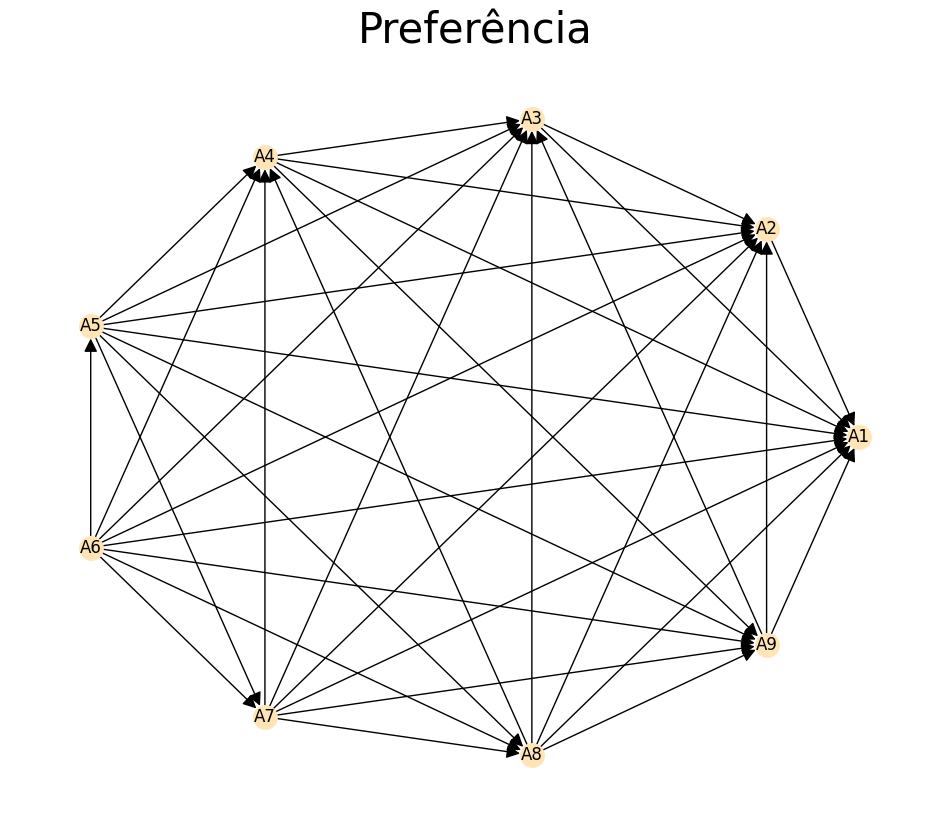

/home/henrique/Documentos/valuation-optimization/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1296: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


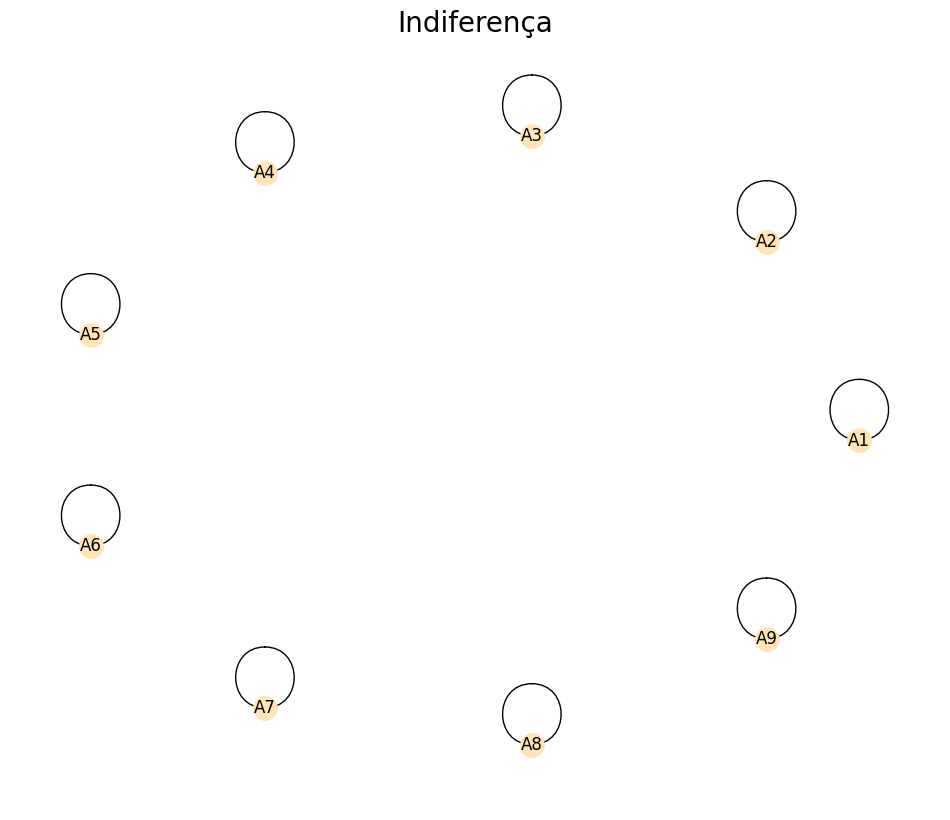

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tabulate import tabulate

# Exemplo de listas para critérios (substitua pelos dados do seu problema)
criterio_1 = [-s[1] for s in filtered_solutions]  # CVaR (vem positivo, mas é negativo)
criterio_2 = [s[2] for s in filtered_solutions]  # FCO
criterio_3 = [s[3] for s in filtered_solutions]  # NPV
criterio_4 = [s[4] for s in filtered_solutions]  # Quantidade Final

# Número de alternativas e critérios
n_alternativas = len(criterio_1)
n_criterios = 4

# Matriz de critérios
criterios = np.array([criterio_1, criterio_2, criterio_3, criterio_4]).T

# Funções de avaliação para os critérios
def G1(x):  # Critério 1: Maximizar (linear)
    # CVaR entre -2655496 e -2452862 - Diferença entre -202634 e +202634
    p = 202634
    return max(0.0, min(1.0, x / p))

def G2(x):  # Critério 2: Maximizar (linear)
    # FCO entre 4468706 e 3872318 - Diferença entre 596388 e -596388
    p = 596388
    return max(0.0, min(1.0, x / p))

def G3(x):  # Critério 3: Maximizar (linear)
    # Custo entre 8653171 e 8317484 - Diferença entre 335687 e -335687
    p = 335687
    return max(0.0, min(1.0, x / p))

def G4(x):  # Critério 4: Maximizar (usual)
    # QOA entre 0 e 1; Simplesmente retornar o valor
    return 1.0 if x > 0.0 else 0.0

# Pesos dos critérios
pesos = pesos_utilizados

# Construção da matriz de preferências parciais
Pj = np.zeros((n_alternativas, n_alternativas, n_criterios))
for i in range(n_alternativas):
    for k in range(n_alternativas):
        for j in range(n_criterios):
            diff = criterios[i, j] - criterios[k, j]
            if j == 0:
                Pj[i, k, j] = G1(diff)
            elif j == 1:
                Pj[i, k, j] = G2(diff)
            elif j == 2:
                Pj[i, k, j] = G3(diff)
            else:
                Pj[i, k, j] = G4(diff)

# Construção da matriz de preferências agregadas
P = np.zeros((n_alternativas, n_alternativas))
for i in range(n_alternativas):
    for k in range(n_alternativas):
        P[i, k] = np.sum(pesos * Pj[i, k, :])

# Exibição da matriz de preferências agregadas
headers = [f"A{i+1}" for i in range(n_alternativas)]
print(tabulate(([headers[i]] + P[i, :].tolist() for i in range(n_alternativas)), headers=headers))

# Fluxos positivos, negativos e finais
phip = np.sum(P, axis=1)  # Fluxo positivo
phim = np.sum(P, axis=0)  # Fluxo negativo
phi = phip - phim         # Fluxo final

# Exibição dos fluxos
print("\nFluxos Positivos:", phip)
print("Fluxos Negativos:", phim)
print("Fluxos Finais:", phi)

# Construção dos grafos de preferências e indiferenças
Pf = phi[:, None] > phi  # Preferência
If = phi[:, None] == phi  # Indiferença

# Grafo de preferência (direcionado)
fig_pref, ax_pref = plt.subplots(figsize=[12, 10])
grafo_pref = nx.DiGraph(Pf)
nx.draw_circular(grafo_pref,
                 ax=ax_pref,
                 arrowsize=20,
                 with_labels=True,
                 labels={i: f"A{i+1}" for i in range(n_alternativas)},
                 node_color='moccasin')
ax_pref.set_title("Preferência", fontsize=30)
plt.show()

# Grafo de indiferença (não-direcionado)
fig_indif, ax_indif = plt.subplots(figsize=[12, 10])
grafo_indif = nx.Graph(If)
nx.draw_circular(grafo_indif,
                 ax=ax_indif,
                 arrowsize=20,
                 with_labels=True,
                 labels={i: f"A{i+1}" for i in range(n_alternativas)},
                 node_color='moccasin')
ax_indif.set_title("Indiferença", fontsize=20)
plt.show()


### Analisando a Solução na Fronteira Pareto

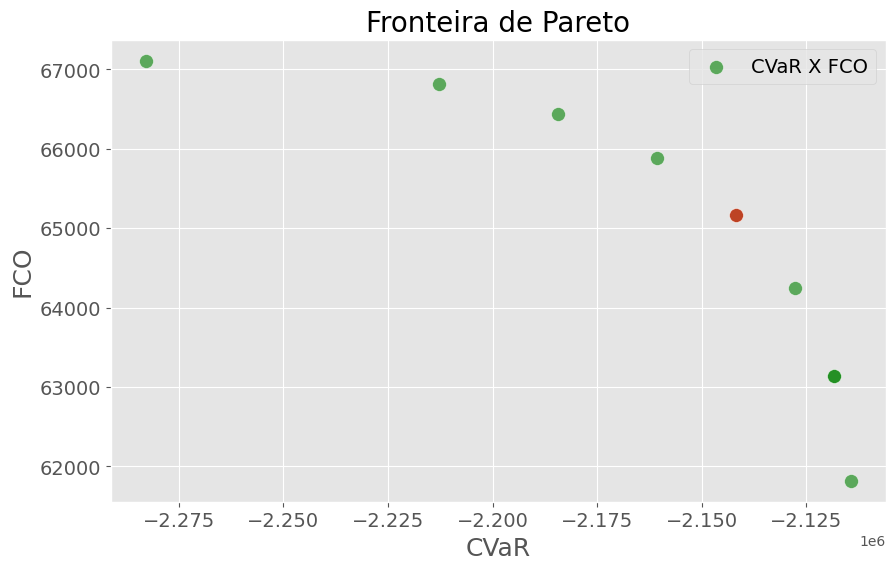

In [135]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=18)
ax2.set_xlabel("CVaR", fontsize=18)
ax2.set_title("Fronteira de Pareto", fontsize=20)
ax2.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[4], criterio_2[4], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

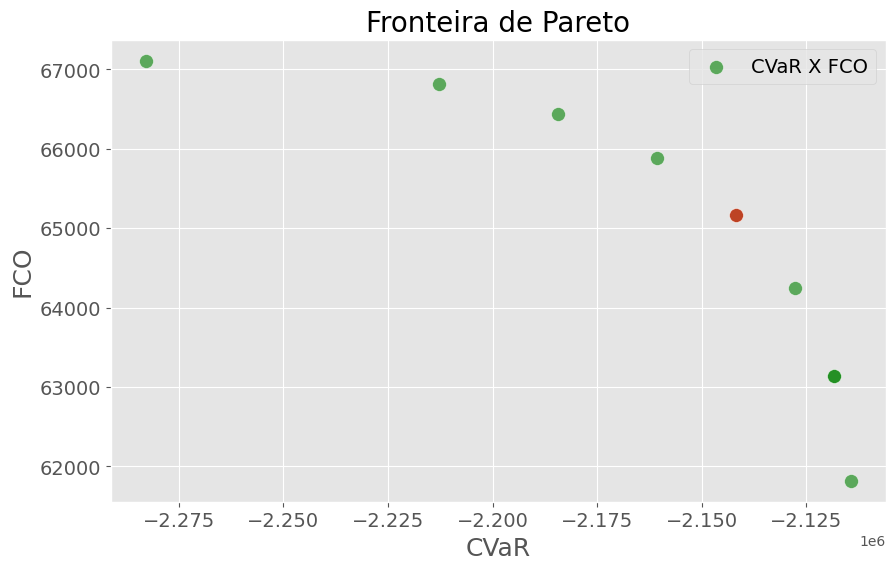

In [136]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=18)
ax2.set_xlabel("CVaR", fontsize=18)
ax2.set_title("Fronteira de Pareto", fontsize=20)
ax2.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[4], criterio_2[4], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

# Realizando a comparação das soluções

In [137]:
from pyomo.environ import *
import numpy as np
import random

# --- 1.1 vetor Q* da solução escolhida ------------------------
Q_star = np.array(filtered_solutions[4][5], dtype=float)  # len == 60

# --- 1.2 instanciar o SEU modelo ------------------------------
T = 60
naive_model = model = ConcreteModel()

model.P = Param(initialize=P_min)                       # preço fixo
model.Q = Var(range(1, T+1), within=NonNegativeReals)
for t in range(1, T+1):
    model.Q[t].fix(Q_star[t-1])                         # 🔒 quantidades

# --- parâmetros que não mudam (copiados do seu bloco) --------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs  = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# --- parâmetros de NCG / outras contas ------------------------
model.theta_AR = Param(initialize=theta_AR)
model.theta_I  = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG      = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# colocaremos model.variable_cost_percentage depois (passo 3)


In [138]:
# --- 2.1 sortear pontos de partida ---------------------------
random.seed(42)                             # reprodutível
MAX_START = len(dolar_mean_variation) - T
starts = random.sample(range(MAX_START+1), k=5)          # 5 janelas

# --- 2.2 construir caminhos vc[t] para cada janela -----------
delta_fx = 0.5
vc0 = 0.35
vc_paths = []                                             # shape (5,60)

for s0 in starts:
    fx_win = dolar_mean_variation[s0 : s0+T-1]            # 59 variações
    vc = [vc0]
    for t in range(1, T):
        vc.append(vc[t-1] + fx_win[t-1]*delta_fx)
    vc_paths.append(vc)


In [139]:
from pyomo.environ import value

# --- 3.1 criar param mutável dos custos ----------------------
model.variable_cost_percentage = Param(
    range(1, T+1),
    initialize=lambda m,t: vc0,     # dummy, será sobrescrito
    mutable=True
)

# --- 3.2 expressões já existentes ----------------------------
def revenue_rule(m,t):   return m.P * m.Q[t]
def AR_rule(m,t):        return revenue_rule(m,t) * m.theta_AR
def I_rule(m,t):         return m.variable_cost_percentage[t] * revenue_rule(m,t) * m.theta_I
def AP_rule(m,t):
    I_prev = I_rule(m,t-1) if t>1 else m.initial_investment
    return (I_rule(m,t) + m.variable_cost_percentage[t]*revenue_rule(m,t) - I_prev)*m.theta_AP
def NCG_rule(m,t):
    if t>1:
        return AR_rule(m,t)+I_rule(m,t)-AP_rule(m,t) - (AR_rule(m,t-1)+I_rule(m,t-1)-AP_rule(m,t-1))
    return AR_rule(m,t)+I_rule(m,t)-AP_rule(m,t) - m.initial_NCG
def FCO_rule(m,t):
    rev = revenue_rule(m,t)
    return (rev
            - m.variable_cost_percentage[t]*rev
            - m.variable_expenses_percentage*rev
            - m.taxes_percentage*rev
            - m.fix_costs - m.fix_expenses
            - NCG_rule(m,t))

model.AR  = Expression(range(1,T+1), rule=AR_rule)
model.I   = Expression(range(1,T+1), rule=I_rule)
model.AP  = Expression(range(1,T+1), rule=AP_rule)
model.NCG = Expression(range(1,T+1), rule=NCG_rule)
model.FCO = Expression(range(1,T+1), rule=FCO_rule)

# --- 3.3 rodar 5 cenários e coletar FCO-12M -------------------
fco_totals = []

for path in vc_paths:
    # sobrescreve o parâmetro de custos variáveis
    for t in range(1, T+1):
        model.variable_cost_percentage[t].set_value(path[t-1])

    # NÃO há variáveis livres => não precisamos solver
    fco12 = sum(value(model.FCO[t]) for t in range(T-12+1, T+1))
    fco_totals.append(fco12)

fco_totals = np.array(fco_totals)


In [140]:
alpha = 0.05
losses = -fco_totals                                  # sinal de “perda”
sorted_losses = np.sort(losses)
idx_var = int(np.ceil(alpha*len(losses))) - 1
VaR  = sorted_losses[idx_var]
CVaR = losses[losses >= VaR].mean()


VaR  (α=0.05): -4,413,169
CVaR (α=0.05): -2,159,766


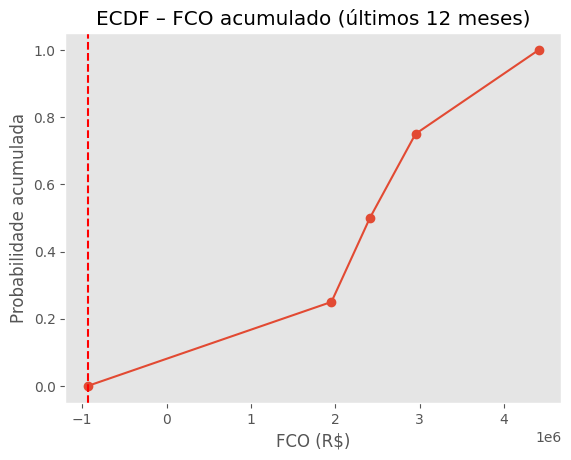

In [141]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

tbl = pd.DataFrame({
    'Cenário': range(1,6),
    'FCO_ultimo12M': fco_totals.astype(int)
})
# display(tbl)

print(f"VaR  (α={alpha:.2f}): {VaR:,.0f}")
print(f"CVaR (α={alpha:.2f}): {CVaR:,.0f}")

# ECDF
sorted_fco = np.sort(fco_totals)
cumprob = np.linspace(0,1,len(sorted_fco))
plt.plot(sorted_fco, cumprob, marker='o')
plt.axvline(sorted_fco[0], ls='--', c='red')
plt.title('ECDF – FCO acumulado (últimos 12 meses)')
plt.xlabel('FCO (R$)'); plt.ylabel('Probabilidade acumulada')
plt.grid(); plt.show()


# Comparação com Markov

In [72]:
# scenarios_alt = np.zeros((scenarios, T))

scenarios_data = scenarios_data_markov.reshape(scenarios, (T-1)).tolist()

values = []
for i in range(scenarios):
    values_list = [initial_variable_costs]
    for t in range(1, T):
        values_list.append(values_list[t-1] + scenarios_data[i][t-1] * dolar_affect_parameter)
    values.append(values_list)

scenarios_data = values

scenarios_data

[[0.35,
  0.3332748096176922,
  0.3459279960596027,
  0.3577627153469649,
  0.3846168534171904,
  0.37708819544566696,
  0.37007254721183336,
  0.3438345327839294,
  0.3504069093457242,
  0.34428565928793287,
  0.33526950739410066,
  0.32729332843545256,
  0.33061821056011814,
  0.32956427156656537,
  0.32263826363427783,
  0.31493117756074784,
  0.3214765734629559,
  0.30988981328187704,
  0.30622079466761276,
  0.3019283821954818,
  0.3033344015192586,
  0.32674003795969153,
  0.33555265233587694,
  0.34614711208750415,
  0.3703575280867354,
  0.3557430317178191,
  0.32933825492249375,
  0.3077919373144213,
  0.2958158209430909,
  0.31387373894646026,
  0.3382070951718671,
  0.34005848031463454,
  0.33336170530526493,
  0.3084998036039765,
  0.33718409039740904,
  0.3675124484710003,
  0.35517460742024354,
  0.33996989705468916,
  0.34451855248875896,
  0.3813295736893744,
  0.3943786188884078,
  0.3922984826228578,
  0.3971538953381648,
  0.38190939512572775,
  0.3893301089533593,
 

In [73]:
from pyomo.environ import *

# Cria um modelo concreto
stochastic_model = model = ConcreteModel()

# Períodos
T=60
S = range(1, 500+1)  # Cenários

# Variáveis de decisão, agora são T * scenarios
model.P = Param(initialize=3)
model.Q = Var(range(1, T+1), bounds=(Q_min, 2*Q_max), within=NonNegativeReals)

# Variáveis para CVaR
model.VarDev = Var(S, within=NonNegativeReals)  # Desvio por cenário
model.VaR = Var(within=Reals)        # Valor em Risco (VaR)
model.CVaR = Var(within=Reals)       # CVaR

# Parâmetros de custos, despesas e impostos
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage = Param(initialize=taxes_percentage)
model.fix_costs = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)

# Agora variable_cost_percentage é um parâmetro que varia em cada cenário
model.variable_cost_percentage = Param(range(1, scenarios+1), range(1, T+1), initialize=lambda model, i, j: scenarios_data[i-1][j-1], mutable=True)

# Parâmetros de elasticidade da demanda
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# Parâmetro de quantidade inicial de vendas
model.initial_quantity = Param(initialize=inital_sales)
model.Q[1].fix(model.initial_quantity)

# Parâmetros de NCG
model.theta_AR = Param(initialize=theta_AR)
model.theta_I = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# Expressões Auxiliares Gerais
def revenue_rule(model, i, t):
    return model.P * model.Q[t]

# Expressões Auxiliares para cálculo da NCG

def AR_rule(model, i, t):
    # return 0
    return revenue_rule(model, i, t) * model.theta_AR

def I_rule(model, i, t):
    # return 0
    return (model.variable_cost_percentage[i, t] * revenue_rule(model, i, t)) * model.theta_I

#TODO: Adicionar o I aqui
def AP_rule(model, i, t):
    i_t_minus_1 = I_rule(model, i, t-1) if t > 1 else model.initial_investment
    return (I_rule(model, i, t) + model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) -i_t_minus_1) * model.theta_AP

def NCG_rule(model, i, t):
    # return AR_rule(model, t) + I_rule(model, t) - AP_rule(model, t) - (AR_rule(model, t-1) + I_rule(model, t-1) - AP_rule(model, t-1) if t > 1 else model.initial_NCG)
    if t > 1:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - (AR_rule(model, i, t-1) + I_rule(model, i, t-1) - AP_rule(model, i, t-1) if t > 1 else model.initial_NCG)
    else:
        return AR_rule(model, i, t) + I_rule(model, i, t) - AP_rule(model, i, t) - model.initial_NCG

def fcf_period_expression(model, i, t_period):
    """
    Calcula o fluxo de caixa livre (FCF) para um dado cenário e período.
    """
    revenue = revenue_rule(model, i, t_period)
    variable_costs = model.variable_cost_percentage[i, t_period] * revenue
    variable_expenses = model.variable_expenses_percentage * revenue
    taxes = model.taxes_percentage * revenue
    fixed_costs = model.fix_costs + model.fix_expenses
    ncg = NCG_rule(model, i, t_period)

    return revenue - variable_costs - variable_expenses - taxes - fixed_costs - ncg

def calculate_wacc(E, D, Ke, Kd, IR):
    """
    Calcula o WACC com base na fórmula fornecida:
    WACC = (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)
    """
    return (E / (E + D)) * Ke + (D / (E + D)) * Kd * (1 - IR)

def objective_rule(model):
    """
    Calcula a função objetivo considerando o fluxo de caixa livre (FCF) descontado
    para múltiplos cenários e períodos.
    """
    t_final = T
    # Valores de exemplo para os parâmetros do WACC (substitua pelos valores reais do modelo)
    E = 0.7  # Capital próprio
    D = 0.3  # Dívida
    Ke = 0.1  # Custo do capital próprio
    Kd = 0.05  # Custo da dívida
    IR = 0.3  # Taxa de imposto

    WACC = calculate_wacc(E, D, Ke, Kd, IR)

    return sum(
        sum(
            fcf_period_expression(model, i, t_period) / ((1 + WACC) ** t_period)
            for i in range(1, scenarios + 1)
        ) / scenarios
        for t_period in range(t_final - months_future_FCO + 1, t_final + 1)
    )

def fco_rule(model, i, t):
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t)) >= 0

# model.fco = Constraint(range(1, scenarios+1), range(1, T+1), rule=fco_rule)

# Restrição de quantidade poder crescer unicamente 10% em cada mês
def growth_rule(model, i, t):
    return model.Q[t] <= model.Q[t-1] * growth_rate if t > 1 else model.Q[t] <= model.initial_quantity

model.growth = Constraint(range(1, scenarios+1), range(1, T+1), rule=growth_rule)

# Restrição de o lucro ser maior ou igual ao mês anterior
def profit_rule(model, i, t):
    if t <= 2:
        # return pyomo true
        return revenue_rule(model, i, t) <= 10e10
    
    return (revenue_rule(model, i, t) -\
        model.variable_cost_percentage[i, t] * revenue_rule(model, i, t) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t) - \
        model.taxes_percentage * revenue_rule(model, i, t) - \
        model.fix_costs - model.fix_expenses) >= ((revenue_rule(model, i, t-1) -\
        model.variable_cost_percentage[i, t-1] * revenue_rule(model, i, t-1) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t-1) - \
        model.taxes_percentage * revenue_rule(model, i, t-1) - \
        model.fix_costs - model.fix_expenses) * profit_increment_rate)

# model.profit = Constraint(range(1, scenarios+1), range(1, T+1), rule=profit_rule)

def non_regression_rule(model, i, t):
    return model.Q[t] >= model.Q[t-1] if t > 1 else model.Q[t] >= model.initial_quantity

model.non_regression = Constraint(range(1, scenarios+1), range(1, T+1), rule=non_regression_rule)

# Restrições para o CVaR
# Restrição para desvio por cenário
def fco_rule_exp(model, i):
    t_final = T
    return -sum(revenue_rule(model, i, t_period) -\
        model.variable_cost_percentage[i, t_period] * revenue_rule(model, i, t_period) - \
        model.variable_expenses_percentage * revenue_rule(model, i, t_period) - \
        model.taxes_percentage * revenue_rule(model, i, t_period) - \
        model.fix_costs - model.fix_expenses - \
        NCG_rule(model, i, t_period) for t_period in range(t_final-months_future_FCO+1, t_final+1))

model.FCO = Expression(S, rule=fco_rule_exp)

def vardev_rule(model, i):
    return model.FCO[i] - model.VaR <= model.VarDev[i]

model.vardev_constraint = Constraint(S, rule=vardev_rule)

# Restrição para definição do CVaR
def cvar_rule(model):
    alpha=0.05
    return model.VaR + (1 / (len(S) * alpha)) * sum(model.VarDev[i] for i in S) == model.CVaR

model.cvar_constraint = Constraint(rule=cvar_rule)

# Componentes da NCG
model.AR = Expression(range(1, scenarios+1), range(1, T+1), rule=AR_rule)
model.I = Expression(range(1, scenarios+1), range(1, T+1), rule=I_rule)
model.AP = Expression(range(1, scenarios+1), range(1, T+1), rule=AP_rule)
model.NCG = Expression(range(1, scenarios+1), range(1, T+1), rule=NCG_rule)

In [74]:
# OBJETIVO

solutions = []
pop_x = []

spaced = 100

for i, beta in enumerate(np.linspace(0.001, 1, spaced)):
    print(f'Iteration {i+1}/{spaced}')
    #  remove objective
    if i > 0:
        model.del_component(model.objective)
    model.objective = Objective(expr=-model.CVaR * beta + (1-beta)*objective_rule(model), sense=maximize)
    solver = SolverFactory(solver_name)
    # solver.options['NonConvex'] = 2
    # result = solver.solve(model, tee=True, warmstart=False) # Válido p/ Gurobi
    result = solver.solve(model, tee=True)
    # Beta, CVaR, FCO, NPV, Quantidade Final, Quantidades Mensais, FCOs, FCOs Mensais

    for j in range(1, scenarios+1):
            fcos_scenarios = [fco_period(model, j, t) for t in range(1, T+1)]

    solutions.append((
        beta, 
        value(model.CVaR), 
        value(objective_rule(model)), 
        value(objective_rule(model)),
        value(model.Q[T]),
        [value(model.Q[t]) for t in range(1, T+1)],
        [value(model.FCO[i]) for i in S],
        fcos_scenarios
    ))

    

    x_sol = []

    # 1) P_{i,t}
    #    model.P[i+1, t+1] no Pyomo => lembre-se que no Pyomo o i e t começam em 1..
    for i_scenario in range(scenarios):
        for t_period in range(T):
            x_sol.append(value(model.P))

    # 2) Q_t
    for t_period in range(T):
        x_sol.append(value(model.Q[t_period+1]))

    # 3) VarDev_i (se existir)
    for i_scenario in range(scenarios):
        # Se não estiver usando, pode colocar 0.0
        # ou, se estiver, use value(model.VarDev[i_scenario+1])
        x_sol.append(0.0)

    # 4) VaR e CVaR (2 vars extras)
    x_sol.append(value(model.VaR))
    x_sol.append(value(model.CVaR))

    pop_x.append(x_sol)


solutions


Iteration 1/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 2/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 3/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 4/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 5/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 6/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 7/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 8/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 9/100
Running HiGHS 1.10.0 (git hash: fd86653): Copyright (c) 2025 HiGHS under MIT licence terms
Iteration 10/100
Running HiGHS 1.10.0

[(np.float64(0.001),
  4320273.013227921,
  72550.76949077747,
  72550.76949077747,
  735083.4992892854,
  [250000.0,
   254861.50000000003,
   259817.53672900004,
   264869.9485482322,
   270020.6095677012,
   275271.4303413547,
   280624.35857577267,
   286081.3798526372,
   291644.5183652516,
   297315.8376693823,
   303097.44144870114,
   308991.4742951126,
   315000.1225042554,
   321125.61488647317,
   327370.22359355557,
   333736.2649615559,
   340226.1003699983,
   346842.1371177933,
   353586.82931618596,
   360462.67879906856,
   367472.23605099524,
   374618.1011532429,
   381902.9247482689,
   389329.4090229238,
   396900.3087107836,
   404618.43211397354,
   412486.6421448619,
   420507.85738801095,
   428685.05318277824,
   437021.2627269706,
   445519.5782019593,
   454183.15191967465,
   463015.19749190466,
   472018.9910223323,
   481197.8723217526,
   490555.2461469214,
   500094.5834634945,
   509819.42273352563,
   519733.3712280018,
   529840.1063649015,
   540143

## Plotagem da Fronteira Pareto

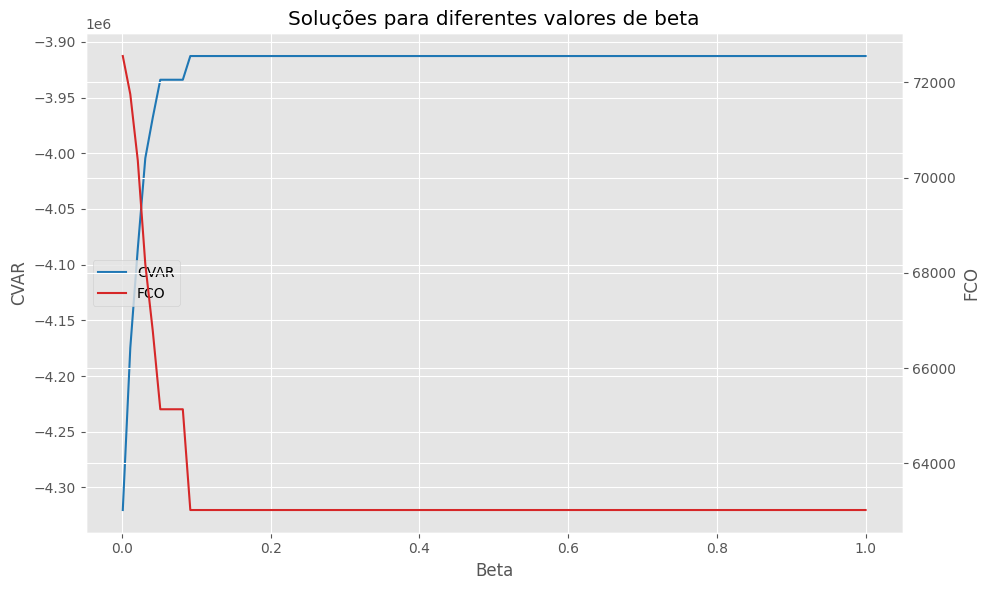

In [75]:
import matplotlib.pyplot as plt

def plot_solutions(solutions):
    # Extraindo as variáveis
    betas = [sol[0] for sol in solutions]
    CVAR = [-sol[1] for sol in solutions]
    FCO = [sol[2] for sol in solutions]

    # Cria a figura e o primeiro eixo
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Cor para a primeira série (CVAR)
    color1 = 'tab:blue'
    ax1.set_xlabel('Beta')
    ax1.set_ylabel('CVAR')
    ax1.plot(betas, CVAR, color=color1, label='CVAR')
    ax1.tick_params(axis='y')
    
    # Cria o segundo eixo (compartilhando o mesmo eixo x)
    ax2 = ax1.twinx()

    # Cor para a segunda série (FCO)
    color2 = 'tab:red'
    ax2.set_ylabel('FCO')
    ax2.plot(betas, FCO, color=color2, label='FCO')
    ax2.tick_params(axis='y')

    # Adiciona título e grade
    plt.title('Soluções para diferentes valores de beta')
    plt.grid(True)
    
    # Ajusta layout para evitar sobreposição
    fig.tight_layout()

    # Cria uma legenda combinada
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc='center left',         # Posição da legenda (centro-esquerda)
    bbox_to_anchor=(0.0, 0.5)  # Ajuste da âncora do bounding box
)

    # Exibe o gráfico
    plt.show()

# Chamada de exemplo
plot_solutions(solutions)


In [76]:
solutions_to_plot = [(s[0], s[1], s[2], s[3], s[4], s[5]) for s in solutions]
# solutions_to_plot = np.array(solutions_to_plot)

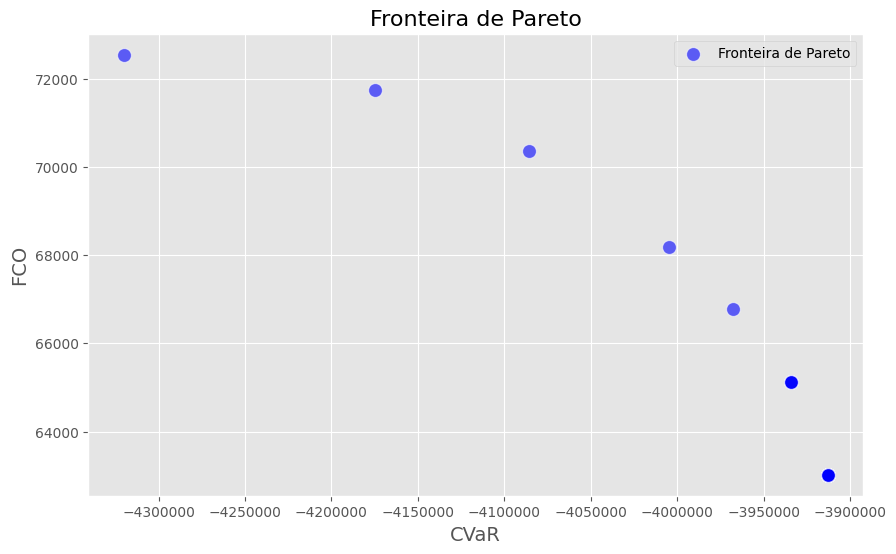

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_pareto(solutions):
    plt.style.use('ggplot')
    figsize = (10, 6)
    marker_size = 100
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Converte as soluções para um array numpy para facilitar a manipulação
    # Retira o elemento da posição 5 antes de converter
    solutions = [s[:5] for s in solutions]
    solutions = np.array(solutions)
    
    # Plota os pontos da fronteira de Pareto usando seaborn
    sns.scatterplot(x=[-s for s in solutions[:, 1]], y=solutions[:, 2], color='blue', s=marker_size, alpha=0.6, edgecolor='w', label='Fronteira de Pareto', ax=ax)
    
    # Coloca os eixos como múltiplos de 10^6
    ax.ticklabel_format(axis='x', style='plain')
    ax.ticklabel_format(axis='y', style='plain')
    
    # Melhorias estéticas
    ax.set_xlabel('CVaR', fontsize=14)
    ax.set_ylabel('FCO', fontsize=14)
    ax.set_title('Fronteira de Pareto', fontsize=16)
    ax.legend()
    ax.grid(True)
    
    plt.show()
    
plot_pareto(solutions_to_plot)

## Filtragem da Fronteira Pareto

In [78]:
filtered_solutions = []
filtered_pop_x = []

for i, sol in enumerate(solutions_to_plot):
    if not any(sol[1] == s[1] and sol[2] == s[2] and sol[3] == s[3] and sol[4] == s[4] for s in filtered_solutions):
        filtered_solutions.append(sol)
        filtered_pop_x.append(pop_x[i])

# filtered_solutions

# Tomada de Decisão

## Variáveis de Decisão

Para a tomada de decisão, é necessário definir as variáveis de decisão que serão utilizadas para a resolução do problema. As variáveis de decisão são as variáveis que podem ser controladas pelo tomador de decisão e que influenciam o resultado do problema. No caso do problema proposto, as variáveis de decisão são:

- FCO dos últimos 12 Meses
- Valor Presente Líquido
- CVaR
- Quantidade de vendas por período

## Algoritmo de Decisão
Em um primeiro momento, será utilizada a abordagem de definição de Pesos pelo AHP e a execução do método TOPSIS para a tomada de decisão. Posteriormente, a abordagem estendida de Bellman-Zadeh será utilizada para a tomada de decisão.

### Descobrindo os Pesos com o AHP

In [79]:
import numpy as np
from tabulate import tabulate


m = 344    # número de alternativas
n = 3      # número de critérios

# Definir os critérios do problema
criterios = ["CVaR (C1)", "FCO (C2)", "NPV (C3)", "Quantidade Final (C4)"]

# Matriz de comparação entre os critérios
# Substitua pelos valores do seu problema
comparison_matrix = np.array([
    [1,   3, 4, 4],  # C1 é 3x mais importante que C2, 4 vezes mais que C3 e 4 vezes mais que C4
    [1/3, 1, 2, 2],  # C2 é 3 vezes menos importante que C1, 2 vezes mais que C3 e 2 vezes mais que C4
    [1/4, 1/2, 1, 1],  # C3 é 4 vezes menos importante que C1, 2 vezes menos que C2 e igual a C4
    [1/4, 1/2, 1, 1]   # C4 é 4 vezes menos importante que C1, 2 vezes menos que C2 e igual a C3
], dtype=float)

# Normalizar
column_sums = np.sum(comparison_matrix, axis=0)          # soma de cada coluna
normalized_matrix = comparison_matrix / column_sums      # normaliza cada coluna
pesos = np.mean(normalized_matrix, axis=1)    

pesos_utilizados = pesos

pesos

array([0.53636364, 0.22045455, 0.12159091, 0.12159091])

### Aplicando o Promethee II

          A1        A2        A3         A4         A5        A6        A7
--  --------  --------  --------  ---------  ---------  --------  --------
A1  0         0.122177  0.123197  0.124787   0.125818   0.127018  0.128567
A2  0.385234  0         0.12261   0.124201   0.125232   0.126432  0.12798
A3  0.536364  0.236146  0         0.123181   0.124212   0.125412  0.126961
A4  0.536364  0.450747  0.214601  0          0.122622   0.123822  0.12537
A5  0.536364  0.536364  0.311495  0.0968945  0          0.122791  0.124339
A6  0.536364  0.536364  0.401008  0.186407   0.0895123  0         0.123139
A7  0.536364  0.536364  0.457361  0.24276    0.145865   0.056353  0

Fluxos Positivos: [0.75156493 1.01168893 1.27227632 1.57352523 1.72824758 1.87279288
 1.97506602]
Fluxos Negativos: [3.06705239 2.41816191 1.63027139 0.89823058 0.733261   0.68182908
 0.75635554]
Fluxos Finais: [-2.31548746 -1.40647298 -0.35799507  0.67529465  0.99498658  1.19096379
  1.21871048]


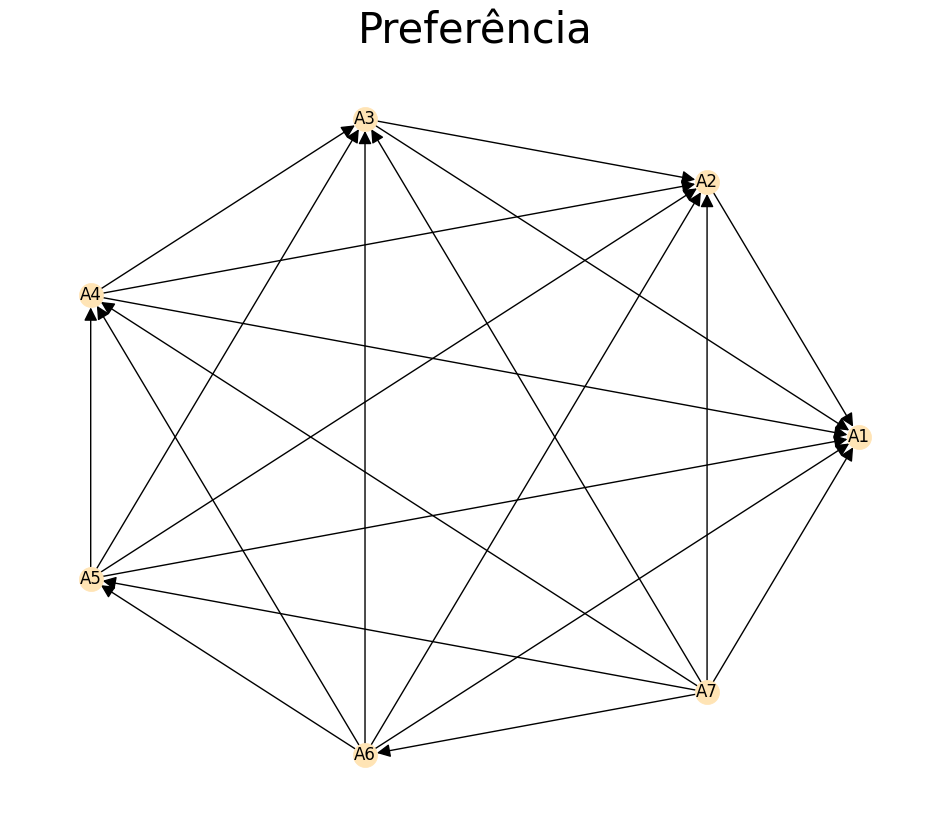

/home/henrique/Documentos/valuation-optimization/.venv/lib/python3.12/site-packages/networkx/drawing/nx_pylab.py:1296: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


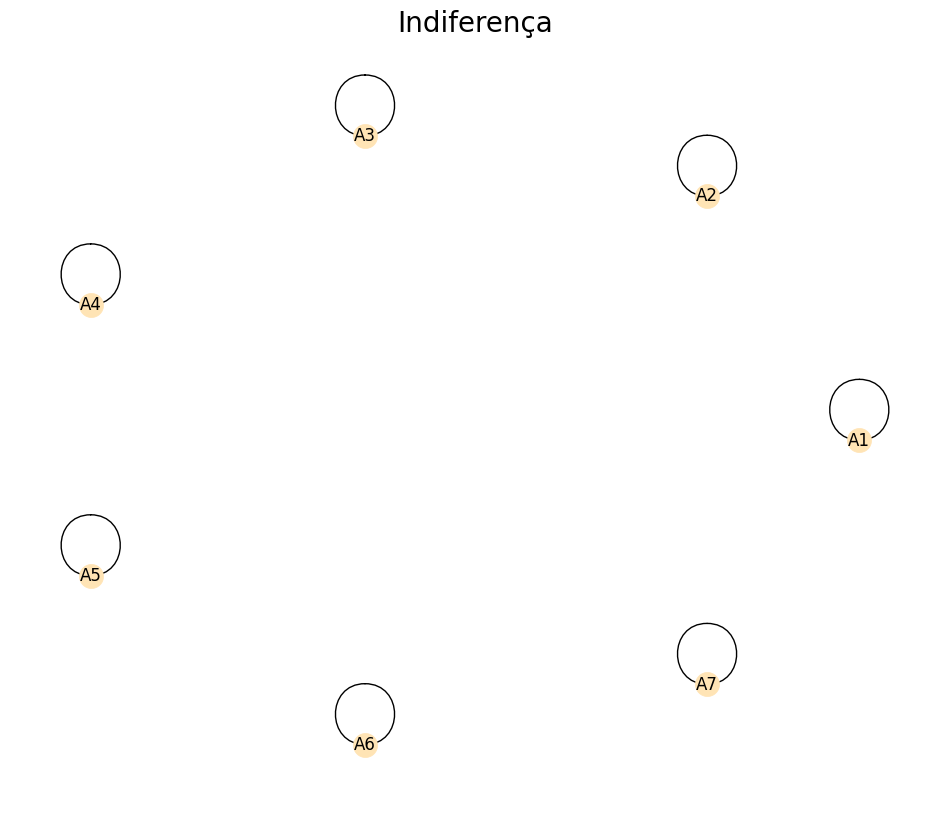

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from tabulate import tabulate

# Exemplo de listas para critérios (substitua pelos dados do seu problema)
criterio_1 = [-s[1] for s in filtered_solutions]  # CVaR (vem positivo, mas é negativo)
criterio_2 = [s[2] for s in filtered_solutions]  # FCO
criterio_3 = [s[3] for s in filtered_solutions]  # NPV
criterio_4 = [s[4] for s in filtered_solutions]  # Quantidade Final

# Número de alternativas e critérios
n_alternativas = len(criterio_1)
n_criterios = 4

# Matriz de critérios
criterios = np.array([criterio_1, criterio_2, criterio_3, criterio_4]).T

# Funções de avaliação para os critérios
def G1(x):  # Critério 1: Maximizar (linear)
    # CVaR entre -2655496 e -2452862 - Diferença entre -202634 e +202634
    p = 202634
    return max(0.0, min(1.0, x / p))

def G2(x):  # Critério 2: Maximizar (linear)
    # FCO entre 4468706 e 3872318 - Diferença entre 596388 e -596388
    p = 596388
    return max(0.0, min(1.0, x / p))

def G3(x):  # Critério 3: Maximizar (linear)
    # Custo entre 8653171 e 8317484 - Diferença entre 335687 e -335687
    p = 335687
    return max(0.0, min(1.0, x / p))

def G4(x):  # Critério 4: Maximizar (usual)
    # QOA entre 0 e 1; Simplesmente retornar o valor
    return 1.0 if x > 0.0 else 0.0

# Pesos dos critérios
pesos = pesos_utilizados

# Construção da matriz de preferências parciais
Pj = np.zeros((n_alternativas, n_alternativas, n_criterios))
for i in range(n_alternativas):
    for k in range(n_alternativas):
        for j in range(n_criterios):
            diff = criterios[i, j] - criterios[k, j]
            if j == 0:
                Pj[i, k, j] = G1(diff)
            elif j == 1:
                Pj[i, k, j] = G2(diff)
            elif j == 2:
                Pj[i, k, j] = G3(diff)
            else:
                Pj[i, k, j] = G4(diff)

# Construção da matriz de preferências agregadas
P = np.zeros((n_alternativas, n_alternativas))
for i in range(n_alternativas):
    for k in range(n_alternativas):
        P[i, k] = np.sum(pesos * Pj[i, k, :])

# Exibição da matriz de preferências agregadas
headers = [f"A{i+1}" for i in range(n_alternativas)]
print(tabulate(([headers[i]] + P[i, :].tolist() for i in range(n_alternativas)), headers=headers))

# Fluxos positivos, negativos e finais
phip = np.sum(P, axis=1)  # Fluxo positivo
phim = np.sum(P, axis=0)  # Fluxo negativo
phi = phip - phim         # Fluxo final

# Exibição dos fluxos
print("\nFluxos Positivos:", phip)
print("Fluxos Negativos:", phim)
print("Fluxos Finais:", phi)

# Construção dos grafos de preferências e indiferenças
Pf = phi[:, None] > phi  # Preferência
If = phi[:, None] == phi  # Indiferença

# Grafo de preferência (direcionado)
fig_pref, ax_pref = plt.subplots(figsize=[12, 10])
grafo_pref = nx.DiGraph(Pf)
nx.draw_circular(grafo_pref,
                 ax=ax_pref,
                 arrowsize=20,
                 with_labels=True,
                 labels={i: f"A{i+1}" for i in range(n_alternativas)},
                 node_color='moccasin')
ax_pref.set_title("Preferência", fontsize=30)
plt.show()

# Grafo de indiferença (não-direcionado)
fig_indif, ax_indif = plt.subplots(figsize=[12, 10])
grafo_indif = nx.Graph(If)
nx.draw_circular(grafo_indif,
                 ax=ax_indif,
                 arrowsize=20,
                 with_labels=True,
                 labels={i: f"A{i+1}" for i in range(n_alternativas)},
                 node_color='moccasin')
ax_indif.set_title("Indiferença", fontsize=20)
plt.show()


### Analisando a Solução na Fronteira Pareto

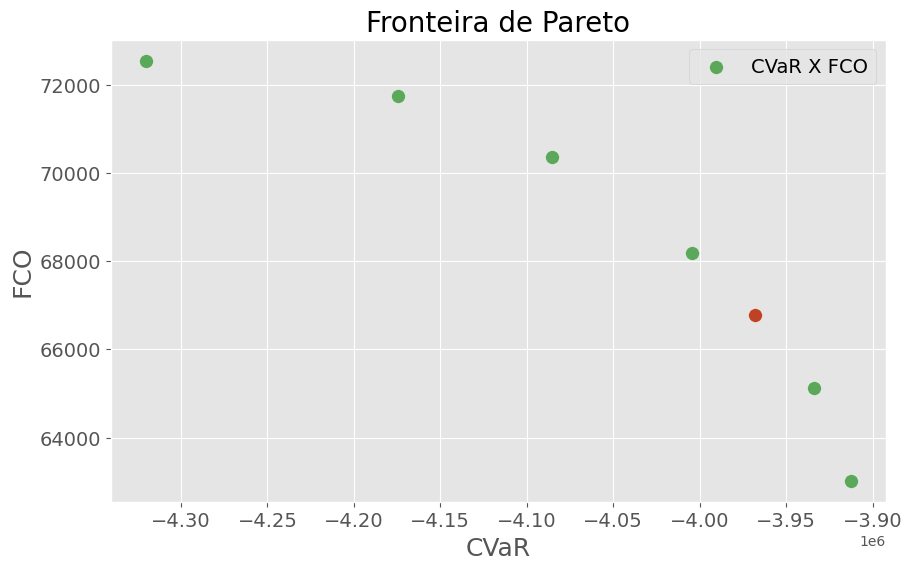

In [81]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=18)
ax2.set_xlabel("CVaR", fontsize=18)
ax2.set_title("Fronteira de Pareto", fontsize=20)
ax2.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[4], criterio_2[4], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

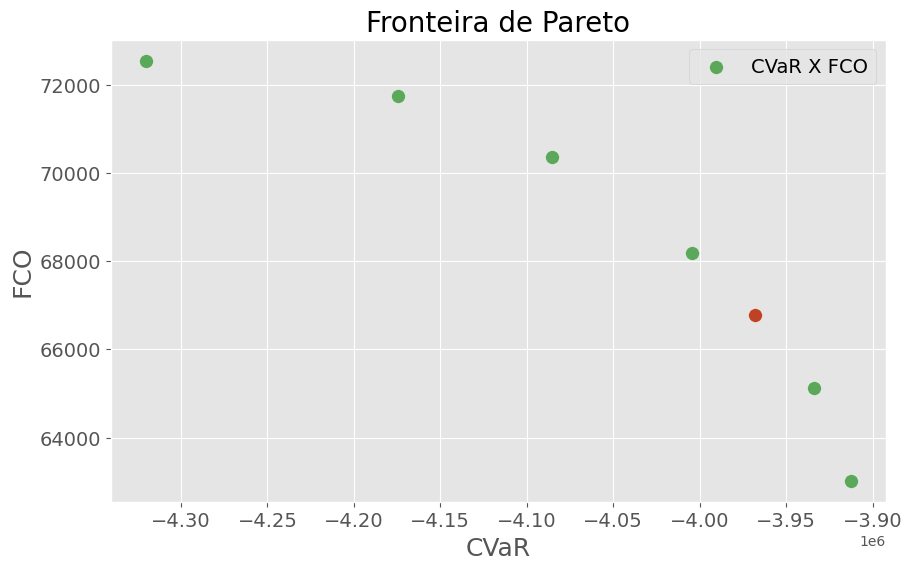

In [82]:
# plt.style.use('ggplot')
figsize = (10, 6)
marker_size = 100

fig2, ax2 = plt.subplots(figsize=figsize)
scatter2 = ax2.scatter(criterio_1, criterio_2, c='green', s=marker_size, alpha=0.6, edgecolors='w', label='CVaR X FCO')
ax2.set_ylabel("FCO", fontsize=18)
ax2.set_xlabel("CVaR", fontsize=18)
ax2.set_title("Fronteira de Pareto", fontsize=20)
ax2.legend(fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax2.grid(True)

# Marcar ponto com [Prioridade, Custo] = [prioridades[19], custos[19]]
ax2.scatter(criterio_1[4], criterio_2[4], c='red', s=marker_size, alpha=0.6, edgecolors='w', label='Solução Ideal')

# Exibir o gráfico
plt.show()

# Realizando a comparação das soluções

In [85]:
from pyomo.environ import *
import numpy as np
import random

# --- 1.1 vetor Q* da solução escolhida ------------------------
Q_star = np.array(filtered_solutions[4][5], dtype=float)  # len == 60

# --- 1.2 instanciar o SEU modelo ------------------------------
T = 60
naive_model = model = ConcreteModel()

model.P = Param(initialize=P_min)                       # preço fixo
model.Q = Var(range(1, T+1), within=NonNegativeReals)
for t in range(1, T+1):
    model.Q[t].fix(Q_star[t-1])                         # 🔒 quantidades

# --- parâmetros que não mudam (copiados do seu bloco) --------
model.variable_expenses_percentage = Param(initialize=variable_expenses_percentage)
model.taxes_percentage             = Param(initialize=taxes_percentage)
model.fix_costs  = Param(initialize=CF)
model.fix_expenses = Param(initialize=DF)
model.a = Param(initialize=a)
model.b = Param(initialize=b)

# --- parâmetros de NCG / outras contas ------------------------
model.theta_AR = Param(initialize=theta_AR)
model.theta_I  = Param(initialize=theta_I)
model.theta_AP = Param(initialize=theta_AP)
model.initial_NCG      = Param(initialize=initial_NCG)
model.initial_investment = Param(initialize=initial_inventory)

# colocaremos model.variable_cost_percentage depois (passo 3)


In [86]:
# --- 2.1 sortear pontos de partida ---------------------------
random.seed(42)                             # reprodutível
MAX_START = len(dolar_mean_variation) - T
starts = random.sample(range(MAX_START+1), k=5)          # 5 janelas

# --- 2.2 construir caminhos vc[t] para cada janela -----------
delta_fx = 0.5
vc0 = 0.35
vc_paths = []                                             # shape (5,60)

for s0 in starts:
    fx_win = dolar_mean_variation[s0 : s0+T-1]            # 59 variações
    vc = [vc0]
    for t in range(1, T):
        vc.append(vc[t-1] + fx_win[t-1]*delta_fx)
    vc_paths.append(vc)


In [87]:
from pyomo.environ import value

# --- 3.1 criar param mutável dos custos ----------------------
model.variable_cost_percentage = Param(
    range(1, T+1),
    initialize=lambda m,t: vc0,     # dummy, será sobrescrito
    mutable=True
)

# --- 3.2 expressões já existentes ----------------------------
def revenue_rule(m,t):   return m.P * m.Q[t]
def AR_rule(m,t):        return revenue_rule(m,t) * m.theta_AR
def I_rule(m,t):         return m.variable_cost_percentage[t] * revenue_rule(m,t) * m.theta_I
def AP_rule(m,t):
    I_prev = I_rule(m,t-1) if t>1 else m.initial_investment
    return (I_rule(m,t) + m.variable_cost_percentage[t]*revenue_rule(m,t) - I_prev)*m.theta_AP
def NCG_rule(m,t):
    if t>1:
        return AR_rule(m,t)+I_rule(m,t)-AP_rule(m,t) - (AR_rule(m,t-1)+I_rule(m,t-1)-AP_rule(m,t-1))
    return AR_rule(m,t)+I_rule(m,t)-AP_rule(m,t) - m.initial_NCG
def FCO_rule(m,t):
    rev = revenue_rule(m,t)
    return (rev
            - m.variable_cost_percentage[t]*rev
            - m.variable_expenses_percentage*rev
            - m.taxes_percentage*rev
            - m.fix_costs - m.fix_expenses
            - NCG_rule(m,t))

model.AR  = Expression(range(1,T+1), rule=AR_rule)
model.I   = Expression(range(1,T+1), rule=I_rule)
model.AP  = Expression(range(1,T+1), rule=AP_rule)
model.NCG = Expression(range(1,T+1), rule=NCG_rule)
model.FCO = Expression(range(1,T+1), rule=FCO_rule)

# --- 3.3 rodar 5 cenários e coletar FCO-12M -------------------
fco_totals = []

for path in vc_paths:
    # sobrescreve o parâmetro de custos variáveis
    for t in range(1, T+1):
        model.variable_cost_percentage[t].set_value(path[t-1])

    # NÃO há variáveis livres => não precisamos solver
    fco12 = sum(value(model.FCO[t]) for t in range(T-12+1, T+1))
    fco_totals.append(fco12)

fco_totals = np.array(fco_totals)


In [88]:
alpha = 0.05
losses = -fco_totals                                  # sinal de “perda”
sorted_losses = np.sort(losses)
idx_var = int(np.ceil(alpha*len(losses))) - 1
VaR  = sorted_losses[idx_var]
CVaR = losses[losses >= VaR].mean()


VaR  (α=0.05): -4,134,509
CVaR (α=0.05): -1,977,654


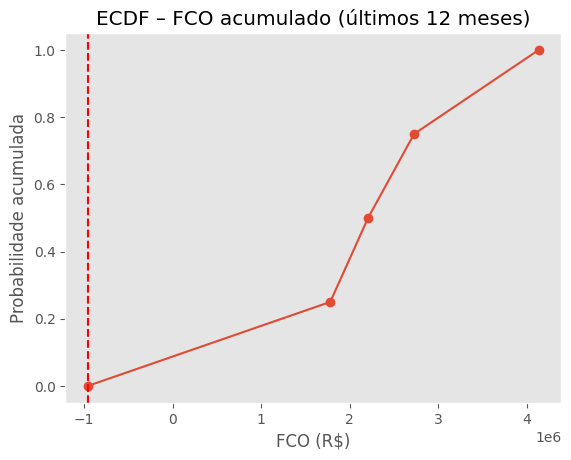

In [90]:
import pandas as pd, matplotlib.pyplot as plt, numpy as np

tbl = pd.DataFrame({
    'Cenário': range(1,6),
    'FCO_ultimo12M': fco_totals.astype(int)
})
# display(tbl)

print(f"VaR  (α={alpha:.2f}): {VaR:,.0f}")
print(f"CVaR (α={alpha:.2f}): {CVaR:,.0f}")

# ECDF
sorted_fco = np.sort(fco_totals)
cumprob = np.linspace(0,1,len(sorted_fco))
plt.plot(sorted_fco, cumprob, marker='o')
plt.axvline(sorted_fco[0], ls='--', c='red')
plt.title('ECDF – FCO acumulado (últimos 12 meses)')
plt.xlabel('FCO (R$)'); plt.ylabel('Probabilidade acumulada')
plt.grid(); plt.show()


## Gráficos da Solução